- Problem being solved - electricty theft
- Problem - Binary classification problem
- Target variable - Normal vs theft

The model learns patterns in the consumption variables and predicts which theft category a new observation belongs to.

# **Import Libraries**

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# **Data Collection**

In [143]:
df = pd.read_csv("electricity_theft_detection file.csv")

In [144]:
df.head()

,0,Electricity:Facility [kW](Hourly),Fans:Electricity [kW](Hourly),Cooling:Electricity [kW](Hourly),Heating:Electricity [kW](Hourly),InteriorLights:Electricity [kW](Hourly),InteriorEquipment:Electricity [kW](Hourly),Gas:Facility [kW](Hourly),Heating:Gas [kW](Hourly),InteriorEquipment:Gas [kW](Hourly),Water Heater:WaterSystems:Gas [kW](Hourly),Class,theft
0,0,22.035977,3.586221,0.0,0.0,4.589925,8.1892,136.585903,123.999076,3.33988,9.246947,FullServiceRestaurant,Normal
1,1,14.649757,0.000000,0.0,0.0,1.529975,7.4902,3.359880,0.000000,3.33988,0.020000,FullServiceRestaurant,Normal
2,2,14.669567,0.000000,0.0,0.0,1.529975,7.4902,3.359880,0.000000,3.33988,0.020000,FullServiceRestaurant,Normal
3,3,14.677808,0.000000,0.0,0.0,1.529975,7.4902,3.931932,0.000000,3.33988,0.592052,FullServiceRestaurant,Normal
4,4,14.824794,0.000000,0.0,0.0,1.529975,7.4902,3.359880,0.000000,3.33988,0.020000,FullServiceRestaurant,Normal


In [145]:
df.tail()

,0,Electricity:Facility [kW](Hourly),Fans:Electricity [kW](Hourly),Cooling:Electricity [kW](Hourly),Heating:Electricity [kW](Hourly),InteriorLights:Electricity [kW](Hourly),InteriorEquipment:Electricity [kW](Hourly),Gas:Facility [kW](Hourly),Heating:Gas [kW](Hourly),InteriorEquipment:Gas [kW](Hourly),Water Heater:WaterSystems:Gas [kW](Hourly),Class,theft
560650,560650,17.388701,1.972876,0.0,0.0,5.481225,1.0116,36.755737,36.755737,0.0,0.0,Warehouse,Theft6
560651,560651,17.274210,1.858385,0.0,0.0,5.481225,1.0116,34.861068,34.861068,0.0,0.0,Warehouse,Theft6
560652,560652,18.231203,2.815379,0.0,0.0,5.481225,1.0116,52.866559,52.866559,0.0,0.0,Warehouse,Theft6
560653,560653,17.737117,2.321293,0.0,0.0,5.481225,1.0116,43.758956,43.758956,0.0,0.0,Warehouse,Theft6
560654,560654,18.413804,2.997979,0.0,0.0,5.481225,1.0116,56.456040,56.456040,0.0,0.0,Warehouse,Theft6


# **Data Cleaning**

In [146]:
df.shape

(560655, 13)

In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 560655 entries, 0 to 560654
Data columns (total 13 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   0                                           560655 non-null  int64  
 1   Electricity:Facility [kW](Hourly)           560655 non-null  float64
 2   Fans:Electricity [kW](Hourly)               560655 non-null  float64
 3   Cooling:Electricity [kW](Hourly)            560655 non-null  float64
 4   Heating:Electricity [kW](Hourly)            560655 non-null  float64
 5   InteriorLights:Electricity [kW](Hourly)     560655 non-null  float64
 6   InteriorEquipment:Electricity [kW](Hourly)  560655 non-null  float64
 7   Gas:Facility [kW](Hourly)                   560655 non-null  float64
 8   Heating:Gas [kW](Hourly)                    560655 non-null  float64
 9   InteriorEquipment:Gas [kW](Hourly)          560655 non-null  float64
 10  Water H

In [148]:
df.isnull().sum()

0                                             0
Electricity:Facility [kW](Hourly)             0
Fans:Electricity [kW](Hourly)                 0
Cooling:Electricity [kW](Hourly)              0
Heating:Electricity [kW](Hourly)              0
InteriorLights:Electricity [kW](Hourly)       0
InteriorEquipment:Electricity [kW](Hourly)    0
Gas:Facility [kW](Hourly)                     0
Heating:Gas [kW](Hourly)                      0
InteriorEquipment:Gas [kW](Hourly)            0
Water Heater:WaterSystems:Gas [kW](Hourly)    0
Class                                         0
theft                                         0
dtype: int64

In [149]:
# dropping irrelevant column
df = df.drop(columns=["0"])

In [150]:
df.columns

Index(['Electricity:Facility [kW](Hourly)', 'Fans:Electricity [kW](Hourly)',
       'Cooling:Electricity [kW](Hourly)', 'Heating:Electricity [kW](Hourly)',
       'InteriorLights:Electricity [kW](Hourly)',
       'InteriorEquipment:Electricity [kW](Hourly)',
       'Gas:Facility [kW](Hourly)', 'Heating:Gas [kW](Hourly)',
       'InteriorEquipment:Gas [kW](Hourly)',
       'Water Heater:WaterSystems:Gas [kW](Hourly)', 'Class', 'theft'],
      dtype='str')

In [151]:
df.duplicated().sum()

np.int64(60856)

# **Exploratory Data Analysis**

# General EDA

In [152]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Electricity:Facility [kW](Hourly),560655.0,161.775593,287.323654,0.0,15.843234,48.197262,155.448375,1726.432223
Fans:Electricity [kW](Hourly),560655.0,13.798083,24.078277,0.0,0.240958,3.557599,14.962478,240.015298
Cooling:Electricity [kW](Hourly),560655.0,43.770035,117.101272,0.0,0.000000,0.078813,16.838516,890.621907
Heating:Electricity [kW](Hourly),560655.0,0.836993,6.123290,0.0,0.000000,0.000000,0.000000,277.996520
InteriorLights:Electricity [kW](Hourly),560655.0,32.988238,65.177701,0.0,3.005316,9.233307,34.382155,448.566544
InteriorEquipment:Electricity [kW](Hourly),560655.0,42.631944,73.493664,0.0,4.950048,15.988889,41.401920,448.566544
Gas:Facility [kW](Hourly),560655.0,77.310902,178.680306,0.0,1.103003,11.905720,66.165380,4491.695087
Heating:Gas [kW](Hourly),560655.0,53.917106,157.721787,0.0,0.000000,0.083226,36.185902,4480.732902
InteriorEquipment:Gas [kW](Hourly),560655.0,8.163785,15.954861,0.0,0.000000,0.451244,7.575135,91.799800
Water Heater:WaterSystems:Gas [kW](Hourly),560655.0,15.230010,52.634413,0.0,0.014510,1.103452,8.517566,783.877898


## Distribution of Columns

In [153]:
energy_cols = ['Electricity:Facility [kW](Hourly)',
       'Fans:Electricity [kW](Hourly)', 'Cooling:Electricity [kW](Hourly)',
       'Heating:Electricity [kW](Hourly)',
       'InteriorLights:Electricity [kW](Hourly)',
       'InteriorEquipment:Electricity [kW](Hourly)',
       'Gas:Facility [kW](Hourly)', 'Heating:Gas [kW](Hourly)',
       'InteriorEquipment:Gas [kW](Hourly)',
       'Water Heater:WaterSystems:Gas [kW](Hourly)']

In [154]:
categorical_cols = ['Class', 'theft']

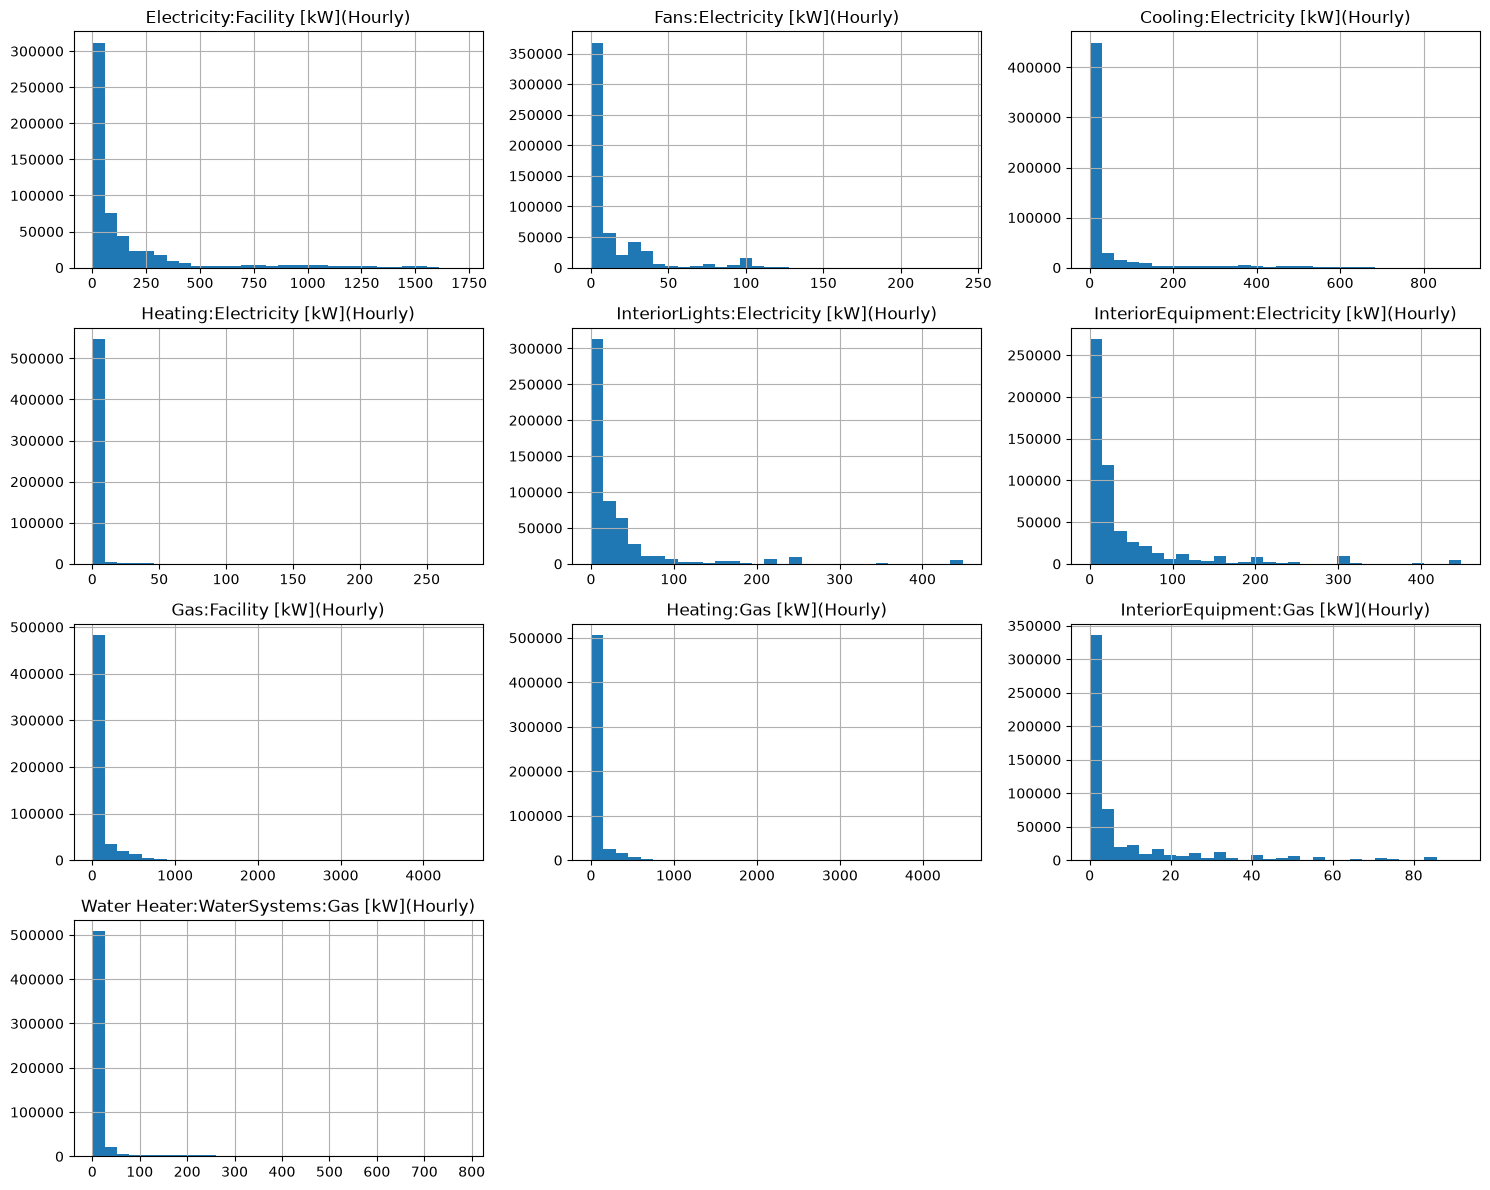

In [155]:
df[energy_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

### Distribution of Class

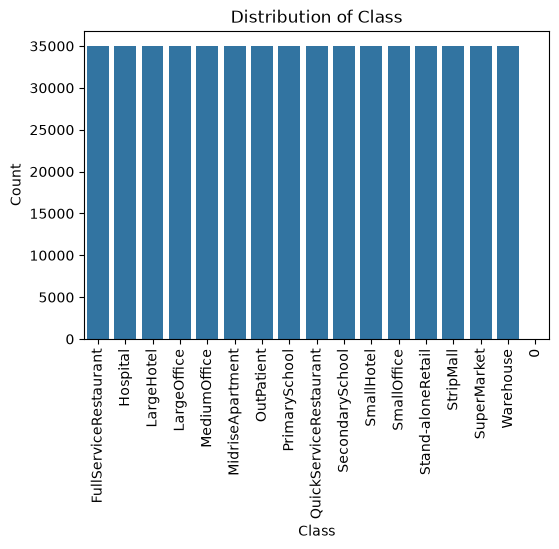

In [156]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Class')

plt.title('Distribution of Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

### Distribution of theft

looking at original classes before creating normal vs. theft

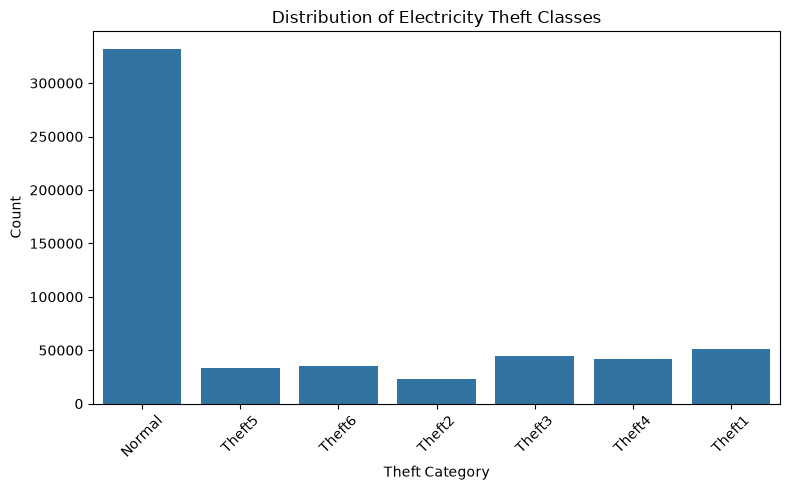

In [157]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='theft')

plt.title('Distribution of Electricity Theft Classes')
plt.xlabel('Theft Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [158]:
print(df['theft'].value_counts())

theft
Normal    331824
Theft1     51083
Theft3     44349
Theft4     41460
Theft6     35413
Theft5     33553
Theft2     22973
Name: count, dtype: int64


In [159]:
print(df['theft'].value_counts(normalize=True) * 100)

theft
Normal    59.185060
Theft1     9.111307
Theft3     7.910212
Theft4     7.394922
Theft6     6.316362
Theft5     5.984607
Theft2     4.097529
Name: proportion, dtype: float64


### Insights
- Dataset is imbalanced with normal as the majority class and theft 2 as the smallest class

## Normal vs. Theft

> Combining all six theft types into one category

In [160]:
# creating a new column
df['theft_binary'] = df['theft'].apply(
    lambda x: 'Normal' if x == 'Normal' else 'Theft')

In [161]:
print(df['theft_binary'].value_counts())

theft_binary
Normal    331824
Theft     228831
Name: count, dtype: int64


In [162]:
print(df['theft_binary'].value_counts(normalize=True) * 100)

theft_binary
Normal    59.18506
Theft     40.81494
Name: proportion, dtype: float64


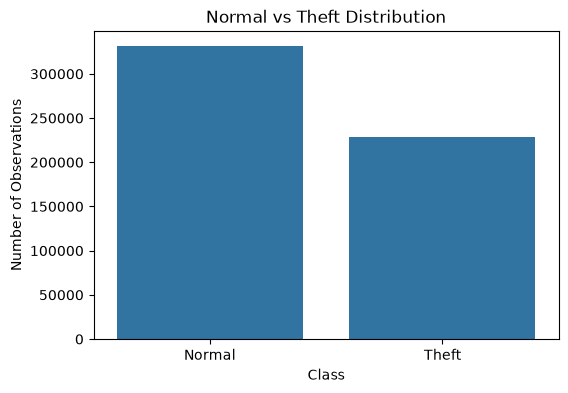

In [163]:
# plot
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='theft_binary')

plt.title('Normal vs Theft Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Observations')

plt.show()

## Insights
- There is some imbalance but not severe

# Outlier Analysis

Actual consumption values for normal vs theft

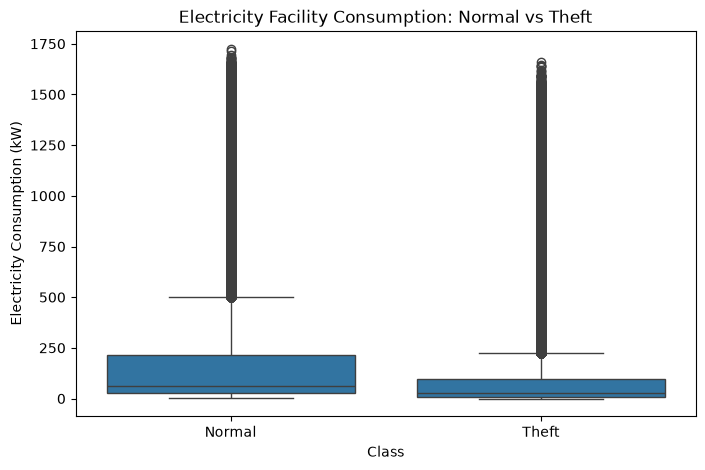

In [164]:
# Electricity:Facility [kW](Hourly)
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='theft_binary',
    y='Electricity:Facility [kW](Hourly)'
)

plt.title('Electricity Facility Consumption: Normal vs Theft')
plt.xlabel('Class')
plt.ylabel('Electricity Consumption (kW)')

plt.show()

## Insights
- The Normal observations generally have a higher median and a wider middle range than the Theft observations.
- The Theft group has a lower typical consumption level.
- Both groups have many high-value observations, shown by the large number of points above the upper whiskers.
- There is substantial overlap between Normal and Theft, so this feature alone won't perfectly separate the two classes. We aren't trying to prove that one variable distinguishes theft by itself. We're checking whether there are patterns across several consumption variables that a classification model could learn.

In [165]:
# looking at the actual values 
col = 'Electricity:Facility [kW](Hourly)'

print(df[col].describe())

count    560655.000000
mean        161.775593
std         287.323654
min           0.000000
25%          15.843234
50%          48.197262
75%         155.448375
max        1726.432223
Name: Electricity:Facility [kW](Hourly), dtype: float64


mean (161.78) is much higher than the median (48.20), this tells us the distribution is strongly right-skewed. That's consistent with what your boxplot showed.

In [166]:
# looking at the very high values
print(df[col].nlargest(20))

171735    1726.432223
170847    1715.694954
171423    1696.751615
170055    1683.445614
167840    1681.692462
170247    1679.955865
167816    1679.526334
171063    1676.926142
168991    1668.280034
170047    1666.231624
168895    1663.343685
174248    1662.076111
170271    1657.878224
170295    1657.878224
173263    1657.689469
167672    1657.455806
171734    1656.889639
172783    1656.785812
169351    1656.614512
170335    1656.453733
Name: Electricity:Facility [kW](Hourly), dtype: float64


Many values range between roughly 1,650Ã¢â‚¬â€œ1,726 kW. Largest values are not all next to one another, but are concentrated in a fairly narrow region of the dataset.

In [167]:
# checking where the high values occur - if in clusters
high_values = df[df[col] > 1000]

print(high_values[[df.columns[0], col, 'theft']].head(20))

      Electricity:Facility [kW](Hourly)  Electricity:Facility [kW](Hourly)  \
8793                        1006.361686                        1006.361686   
8794                        1001.654910                        1001.654910   
8795                        1009.036043                        1009.036043   
8798                        1001.716161                        1001.716161   
8799                        1011.649991                        1011.649991   
8800                        1022.021485                        1022.021485   
8801                        1020.039246                        1020.039246   
8818                        1000.883161                        1000.883161   
8819                        1002.755537                        1002.755537   
8821                        1005.103321                        1005.103321   
8822                        1005.807376                        1005.807376   
8823                        1018.668891                        1

In [168]:
# check how many they are
print("Number above 1000 kW:", len(high_values))

Number above 1000 kW: 23265


23,265 observations are above 1,000 kW, which is about 4.15% of the dataset. That's quite a lot for us to immediately assume they are errors.

In [169]:
print(high_values['theft'].value_counts())

theft
Normal    19407
Theft5     2017
Theft6     1457
Theft1      241
Theft3      143
Name: count, dtype: int64


high values occur in the Normal class as well as several Theft classes

In [170]:
col = 'Electricity:Facility [kW](Hourly)'

print(
    df.groupby('theft')[col]
      .describe()[['mean', '50%', '75%', 'max']]
)

              mean        50%         75%          max
theft                                                 
Normal  200.939944  61.591813  214.926180  1726.432223
Theft1   88.599673  26.855567   83.450064  1261.101369
Theft2    0.000000   0.000000    0.000000     0.000000
Theft3   89.545667  26.708972   83.566972  1226.402672
Theft4   62.187932  19.281296   62.663641   991.417106
Theft5  210.057133  69.267124  220.000604  1383.306907
Theft6  166.606691  51.219251  164.717543  1657.878224


Looking at median of all classes, the high values are not simply errors since different theft categories have different consumption patterns. Theft2 is exactly zero for every observation.

### Insights
- The energy-consumption variables exhibited numerous statistical outliers. However, these observations were retained because they may represent genuine high-consumption periods and are present across different theft categories. Further investigation was performed before considering any removal or transformation.

In [171]:
df.columns

Index(['Electricity:Facility [kW](Hourly)', 'Fans:Electricity [kW](Hourly)',
       'Cooling:Electricity [kW](Hourly)', 'Heating:Electricity [kW](Hourly)',
       'InteriorLights:Electricity [kW](Hourly)',
       'InteriorEquipment:Electricity [kW](Hourly)',
       'Gas:Facility [kW](Hourly)', 'Heating:Gas [kW](Hourly)',
       'InteriorEquipment:Gas [kW](Hourly)',
       'Water Heater:WaterSystems:Gas [kW](Hourly)', 'Class', 'theft',
       'theft_binary'],
      dtype='str')

In [172]:
print(df[energy_cols].describe().T)

                                               count        mean         std  \
Electricity:Facility [kW](Hourly)           560655.0  161.775593  287.323654   
Fans:Electricity [kW](Hourly)               560655.0   13.798083   24.078277   
Cooling:Electricity [kW](Hourly)            560655.0   43.770035  117.101272   
Heating:Electricity [kW](Hourly)            560655.0    0.836993    6.123290   
InteriorLights:Electricity [kW](Hourly)     560655.0   32.988238   65.177701   
InteriorEquipment:Electricity [kW](Hourly)  560655.0   42.631944   73.493664   
Gas:Facility [kW](Hourly)                   560655.0   77.310902  178.680306   
Heating:Gas [kW](Hourly)                    560655.0   53.917106  157.721787   
InteriorEquipment:Gas [kW](Hourly)          560655.0    8.163785   15.954861   
Water Heater:WaterSystems:Gas [kW](Hourly)  560655.0   15.230010   52.634413   

                                            min        25%        50%  \
Electricity:Facility [kW](Hourly)           0.

In [173]:
# Statistical outliers each varible has
for col in energy_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f'{col}')
    print(f'  Lower bound: {lower:.2f}')
    print(f'  Upper bound: {upper:.2f}')
    print(f'  Outliers: {len(outliers):,}')
    print()

Electricity:Facility [kW](Hourly)
  Lower bound: -193.56
  Upper bound: 364.86
  Outliers: 61,090

Fans:Electricity [kW](Hourly)
  Lower bound: -21.84
  Upper bound: 37.04
  Outliers: 50,063

Cooling:Electricity [kW](Hourly)
  Lower bound: -25.26
  Upper bound: 42.10
  Outliers: 95,949

Heating:Electricity [kW](Hourly)
  Lower bound: 0.00
  Upper bound: 0.00
  Outliers: 57,890

InteriorLights:Electricity [kW](Hourly)
  Lower bound: -44.06
  Upper bound: 81.45
  Outliers: 46,357

InteriorEquipment:Electricity [kW](Hourly)
  Lower bound: -49.73
  Upper bound: 96.08
  Outliers: 67,805

Gas:Facility [kW](Hourly)
  Lower bound: -96.49
  Upper bound: 163.76
  Outliers: 73,149

Heating:Gas [kW](Hourly)
  Lower bound: -54.28
  Upper bound: 90.46
  Outliers: 80,904

InteriorEquipment:Gas [kW](Hourly)
  Lower bound: -11.36
  Upper bound: 18.94
  Outliers: 79,810

Water Heater:WaterSystems:Gas [kW](Hourly)
  Lower bound: -12.74
  Upper bound: 21.27
  Outliers: 60,012



## Insights
- The energy variables are strongly right-skewed - for most features, the mean is considerably higher than the median, and the maximum values are much larger than the 75th percentile. This indicates that most observations have relatively low consumption, with a smaller number of observations having substantially higher consumption.
- The IQR method identifies many high values as statistical outliers - however, this does not automatically mean the values are erroneous. Given the nature of energy-consumption data, these could represent genuine periods of high consumption. Therefore they shouldn't be removed simply because they fall outside the IQR limits.
- The variables have very different scales - for example, Gas:Facility reaches over 4,000 kW, while Heating:Electricity has a maximum below 300 kW. This will become relevant later when preprocessing the data for machine learning.

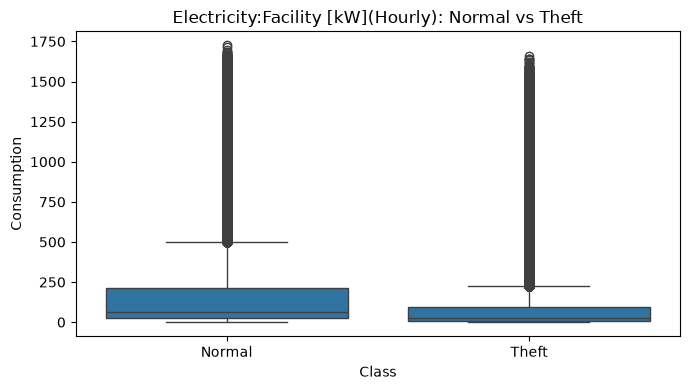

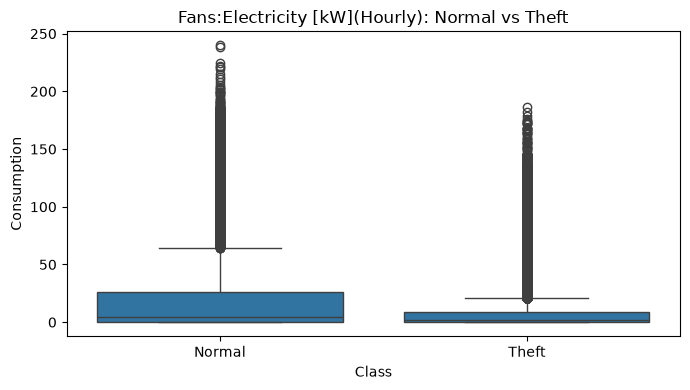

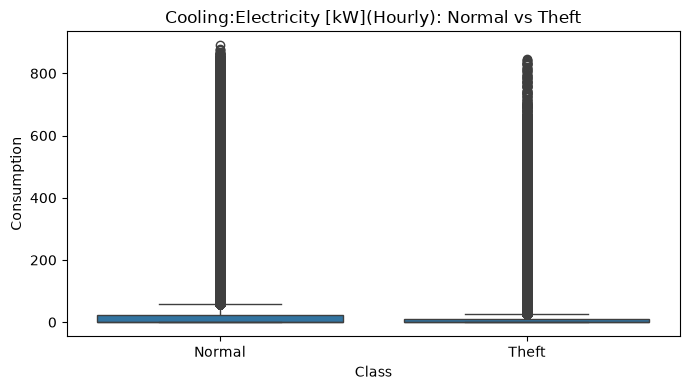

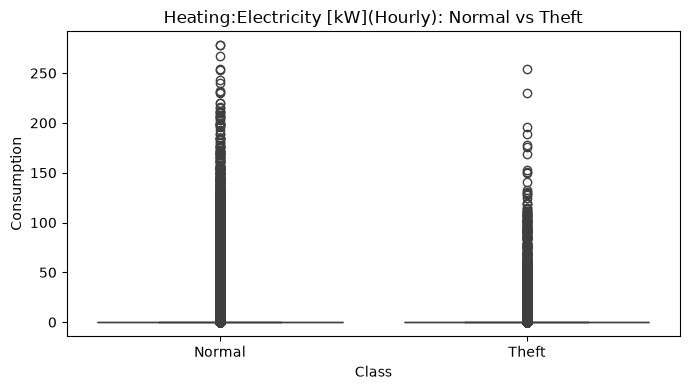

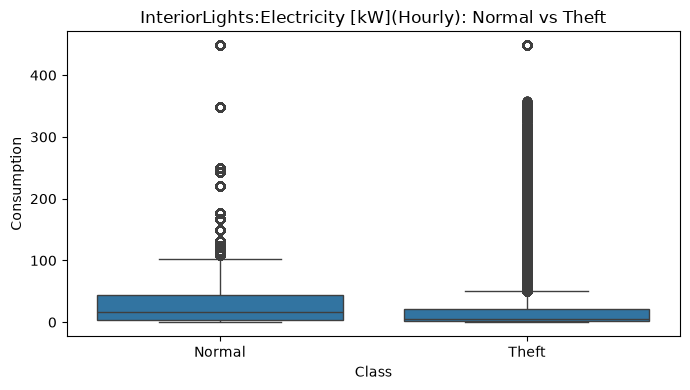

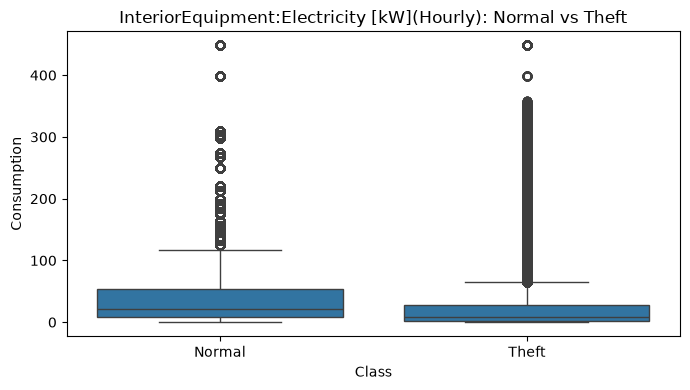

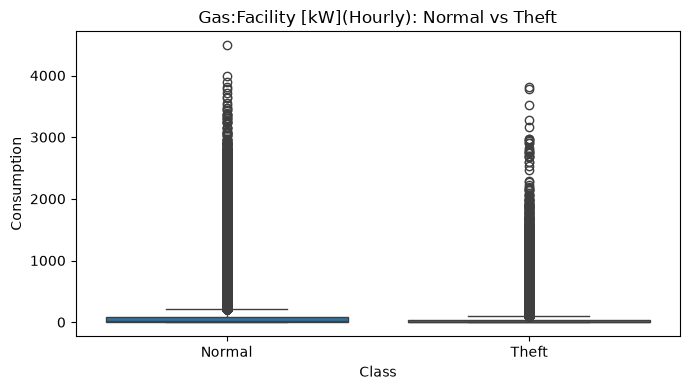

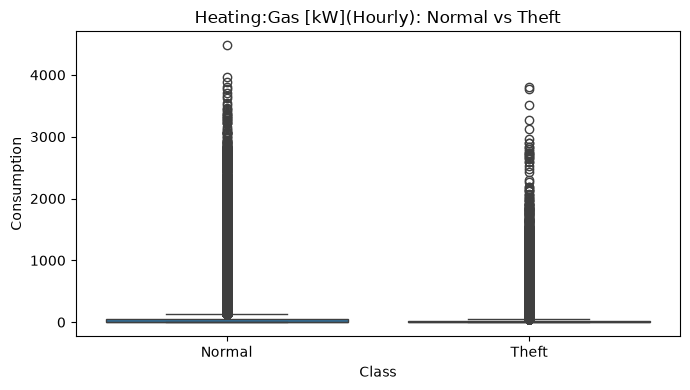

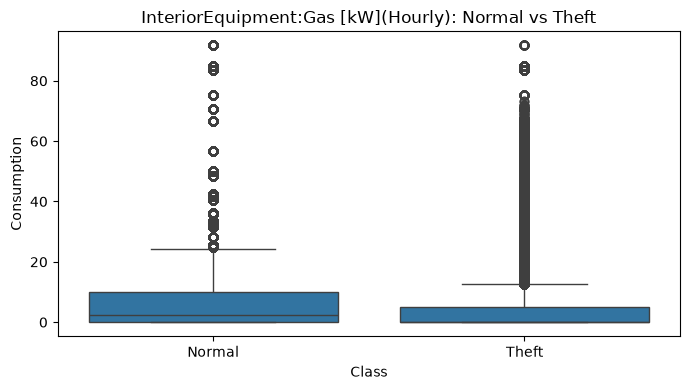

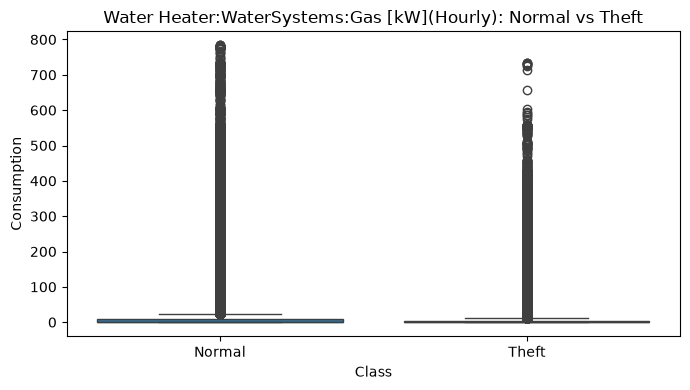

In [174]:
for col in energy_cols:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(
        data=df,
        x='theft_binary',
        y=col
    )
    
    plt.title(f'{col}: Normal vs Theft')
    plt.xlabel('Class')
    plt.ylabel('Consumption')
    plt.tight_layout()
    plt.show()

## Inisghts

Boxplots and the IQR method identified numerous statistical outliers across the energy-consumption variables. However, the observations were retained because extreme consumption values may represent genuine operational conditions rather than measurement errors

In [175]:
# analyzing theft2
theft2 = df[df['theft'] == 'Theft2']

print(theft2[energy_cols].describe().T)

                                              count  mean  std  min  25%  50%  \
Electricity:Facility [kW](Hourly)           22973.0   0.0  0.0  0.0  0.0  0.0   
Fans:Electricity [kW](Hourly)               22973.0   0.0  0.0  0.0  0.0  0.0   
Cooling:Electricity [kW](Hourly)            22973.0   0.0  0.0  0.0  0.0  0.0   
Heating:Electricity [kW](Hourly)            22973.0   0.0  0.0  0.0  0.0  0.0   
InteriorLights:Electricity [kW](Hourly)     22973.0   0.0  0.0  0.0  0.0  0.0   
InteriorEquipment:Electricity [kW](Hourly)  22973.0   0.0  0.0  0.0  0.0  0.0   
Gas:Facility [kW](Hourly)                   22973.0   0.0  0.0  0.0  0.0  0.0   
Heating:Gas [kW](Hourly)                    22973.0   0.0  0.0  0.0  0.0  0.0   
InteriorEquipment:Gas [kW](Hourly)          22973.0   0.0  0.0  0.0  0.0  0.0   
Water Heater:WaterSystems:Gas [kW](Hourly)  22973.0   0.0  0.0  0.0  0.0  0.0   

                                            75%  max  
Electricity:Facility [kW](Hourly)           0.0  0.0 

Theft2 observations have zero values across all energy-consumption features. Retain the zeros without treating them as missing values.

# Correlation Analysis

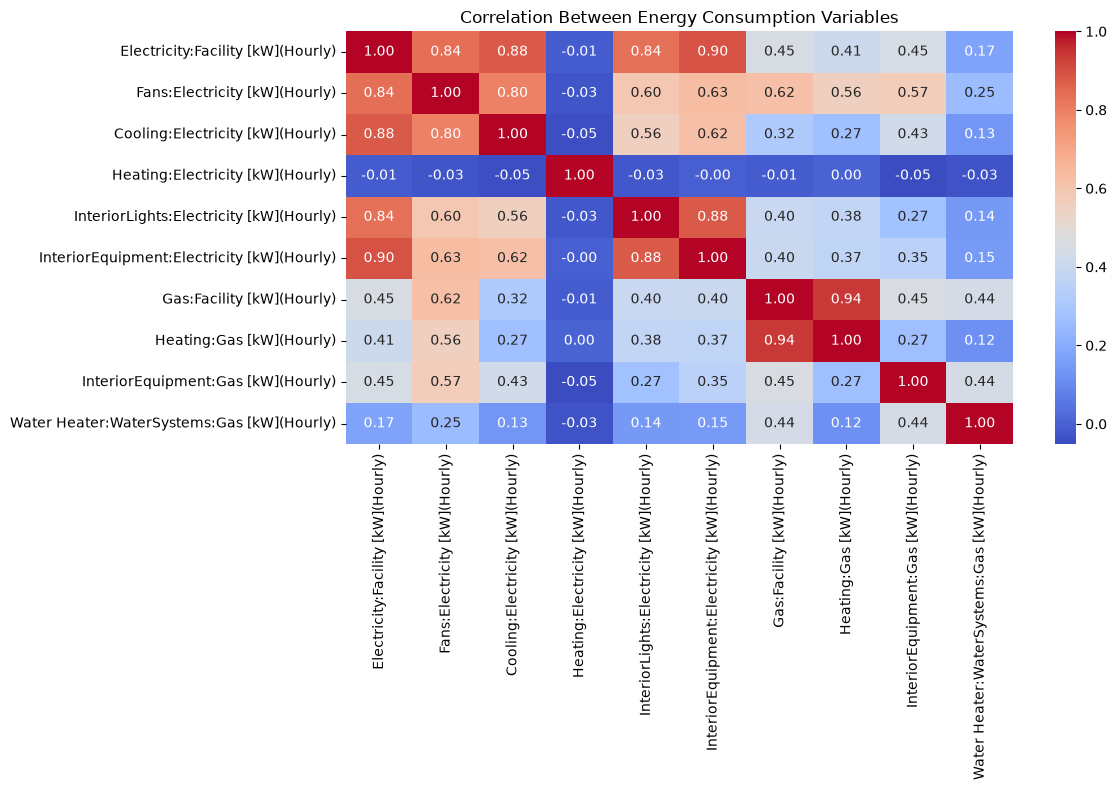

In [176]:
# check correlation
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[energy_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Between Energy Consumption Variables')
plt.tight_layout()
plt.show()

## Inisghts
- Fans and Cooling have a strong positive correlation (0.80) - when cooling consumption increases, fan consumption tends to increase as well. This makes sense because both are related to building cooling/ventilation.

- Interior Lights and Interior Equipment are very strongly correlated (0.88) - their consumption patterns tend to move together, likely reflecting overall building activity/occupancy.

- Gas Facility and Heating Gas have an extremely strong correlation (0.94) - heating gas is a major component of total gas consumption.

- Fans, Cooling, and several other electricity variables show moderate positive correlations - for example, Fans with Interior Equipment (0.63) and Interior Lights (0.60). This suggests that general building activity affects several electricity-consuming systems simultaneously.

- Heating Electricity is almost uncorrelated with most variables - correlations are close to 0. This suggests its consumption pattern is relatively independent of the other energy variables, possibly because it is zero for many observations.

- Water Heater Gas has generally weak-to-moderate correlations - its strongest relationships are with Gas Facility (0.44) and Interior Equipment Gas (0.44), while its relationship with Cooling is very weak (0.13).

## Multicollinearity with VIF (Variance Inflation Factor)
> - VIF = 1: No correlation
> - VIF < OR = 5: Moderate correlation
> - VIF > 5 (OR> 10): High Multicollinearity

In [177]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select the energy variables
X = df[energy_cols]

# Calculate VIF
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

C:\Users\User\AppData\Local\Temp\ipykernel_22804\3097356262.py:10: UserWarning: The design matrix is poorly conditioned (condition number=1.65e+10). VIF calculations may be numerically unstable.
  variance_inflation_factor(X.values, i)


,Feature,VIF
8,InteriorEquipment:Gas [kW](Hourly),1.000800e+15
9,Water Heater:WaterSystems:Gas [kW](Hourly),1.000800e+15
7,Heating:Gas [kW](Hourly),1.000800e+15
6,Gas:Facility [kW](Hourly),1.000800e+15
0,Electricity:Facility [kW](Hourly),8.786475e+01
5,InteriorEquipment:Electricity [kW](Hourly),1.922011e+01
2,Cooling:Electricity [kW](Hourly),1.819243e+01
1,Fans:Electricity [kW](Hourly),7.942515e+00
4,InteriorLights:Electricity [kW](Hourly),6.727431e+00
3,Heating:Electricity [kW](Hourly),1.028640e+00


## Inisghts
- Gas-related variables show extremely high VIF values (~1 Ãƒâ€” 10Ã‚Â¹Ã¢ÂÂµ).
This indicates severe multicollinearity among Gas:Facility, Heating:Gas, InteriorEquipment:Gas, and Water Heater:WaterSystems:Gas. 

- Gas Facility and Heating Gas are especially redundant.
Their correlation was 0.94, so they carry very similar information. The extremely high VIF confirms that the relationship is strong enough to cause numerical multicollinearity.

- Fans has a VIF of 5.23.
This indicates moderate-to-high multicollinearity. Its relationship with variables such as Cooling (0.80) and Interior Equipment Electricity (0.63) likely contributes to this.

- Interior Equipment Electricity has a VIF of 5.14.
This is also around the commonly used threshold of 5, suggesting that it overlaps substantially with other electricity variables, particularly Interior Lights (0.88).

- Interior Lights has a VIF of 4.68.
This indicates noticeable but not severe multicollinearity. Its strong correlation with Interior Equipment Electricity is likely an important contributor.

- Cooling has a VIF of 3.47.
This suggests some relationship with the other variables, but multicollinearity is not particularly concerning.

- Heating Electricity has a VIF of approximately 1.01.
This indicates almost no multicollinearity with the other energy variables. This agrees with the correlation heatmap, where Heating Electricity had correlations close to zero with most variables.

overall:
- The VIF results show that multicollinearity is mainly concentrated among the gas variables, while the electricity variables have moderate levels of overlap. This means several energy features are measuring related aspects of consumption rather than completely independent patterns.
- Not remove the gas variables at this EDA stage. The extremely large VIF values tell us that they are highly redundant, but for theft detection, those relationships may themselves contain useful information.

# Removing Heating:Gas [kW](Hourly) 
- it is redundant with high multicollinearity with Gas:Facility [kW](Hourly) of 0.94. Removed heating gas since gas facility represents total facility gas consumption while heating gas appears to be one component of that total.

In [178]:
df = df.drop(columns=['Heating:Gas [kW](Hourly)'])

In [179]:
energy_cols_reduced = [
    'Fans:Electricity [kW](Hourly)',
    'Cooling:Electricity [kW](Hourly)',
    'Heating:Electricity [kW](Hourly)',
    'InteriorLights:Electricity [kW](Hourly)',
    'InteriorEquipment:Electricity [kW](Hourly)',
    'Gas:Facility [kW](Hourly)',
    'InteriorEquipment:Gas [kW](Hourly)',
    'Water Heater:WaterSystems:Gas [kW](Hourly)'
]

## Comparing energy consumption between Normal and Theft

In [180]:
df.groupby('theft_binary')[energy_cols_reduced].mean().T

theft_binary,Normal,Theft
Fans:Electricity [kW](Hourly),17.068648,9.055492
Cooling:Electricity [kW](Hourly),54.153962,28.712476
Heating:Electricity [kW](Hourly),1.072650,0.495273
InteriorLights:Electricity [kW](Hourly),40.964893,21.421423
InteriorEquipment:Electricity [kW](Hourly),53.121110,27.421781
Gas:Facility [kW](Hourly),95.803915,50.494493
InteriorEquipment:Gas [kW](Hourly),10.003333,5.496289
Water Heater:WaterSystems:Gas [kW](Hourly),18.746502,10.130805


## Insight
- Normal observations have higher average consumption across every energy variable compared with Theft observations.
- Cooling shows a large difference: Normal averages about 54.15 kW, while Theft averages 28.71 kW. This suggests that reduced cooling consumption may be an important indicator of theft.
- All variables follow the same direction: Normal > Theft. This consistency is important because it suggests that theft observations generally have reduced consumption across multiple systems, rather than the difference being isolated to one particular energy source.

Overall
- The mean values show a clear separation in average energy consumption between Normal and Theft. Theft observations consistently consume less electricity and gas, which suggests that the energy features contain useful information for distinguishing the two classes.

In [181]:
df.groupby('theft_binary')[energy_cols_reduced].median().T

theft_binary,Normal,Theft
Fans:Electricity [kW](Hourly),4.459416,2.043478
Cooling:Electricity [kW](Hourly),0.069442,0.086795
Heating:Electricity [kW](Hourly),0.000000,0.000000
InteriorLights:Electricity [kW](Hourly),15.863942,5.943728
InteriorEquipment:Electricity [kW](Hourly),20.643869,8.377474
Gas:Facility [kW](Hourly),18.664312,6.650241
InteriorEquipment:Gas [kW](Hourly),2.335000,0.000000
Water Heater:WaterSystems:Gas [kW](Hourly),1.165454,0.581050


## Insights
- Most variables have lower median consumption for Theft than Normal, reinforcing the pattern we saw in the means.
- Interior Equipment Gas has a particularly interesting pattern: its median is 2.34 kW for Normal but 0 for Theft. This means at least half of the Theft observations have zero consumption for this variable.
- Heating Electricity has a median of 0 for both classes. This means heating electricity is zero in at least half of both Normal and Theft observations, so the median doesn't distinguish the classes here.
- Cooling is also interesting: the median is 0.069 kW for Normal and 0.087 kW for Theft, which is slightly higher for Theft. This contrasts with the means (54.15 vs 28.71 kW), indicating that the Cooling variable is strongly skewed and has some large values that substantially increase the mean.

Overall
- This suggests that the distribution and extreme/high consumption periods may be particularly important for Cooling, rather than just its typical hourly consumption.

# Building type analysis

In [182]:
# checking how many observations of each building type
df['Class'].value_counts()

Class
FullServiceRestaurant     35040
Hospital                  35040
LargeHotel                35040
LargeOffice               35040
MediumOffice              35040
MidriseApartment          35040
OutPatient                35040
PrimarySchool             35040
QuickServiceRestaurant    35040
SecondarySchool           35040
SmallHotel                35040
SmallOffice               35040
Stand-aloneRetail         35040
StripMall                 35040
SuperMarket               35040
Warehouse                 35040
0                            15
Name: count, dtype: int64

In [183]:
df['Class'].head(20)

0     FullServiceRestaurant
1     FullServiceRestaurant
2     FullServiceRestaurant
3     FullServiceRestaurant
4     FullServiceRestaurant
5     FullServiceRestaurant
6     FullServiceRestaurant
7     FullServiceRestaurant
8     FullServiceRestaurant
9     FullServiceRestaurant
10    FullServiceRestaurant
11    FullServiceRestaurant
12    FullServiceRestaurant
13    FullServiceRestaurant
14    FullServiceRestaurant
15    FullServiceRestaurant
16    FullServiceRestaurant
17    FullServiceRestaurant
18    FullServiceRestaurant
19    FullServiceRestaurant
Name: Class, dtype: str

In [184]:
df['Class'].tail(20)

560635    Warehouse
560636    Warehouse
560637    Warehouse
560638    Warehouse
560639    Warehouse
560640    Warehouse
560641    Warehouse
560642    Warehouse
560643    Warehouse
560644    Warehouse
560645    Warehouse
560646    Warehouse
560647    Warehouse
560648    Warehouse
560649    Warehouse
560650    Warehouse
560651    Warehouse
560652    Warehouse
560653    Warehouse
560654    Warehouse
Name: Class, dtype: str

In [185]:
# checking normal vs theft within each building type
pd.crosstab(df['Class'], df['theft_binary'])

theft_binary,Normal,Theft
Class,,
0,0,15
FullServiceRestaurant,20778,14262
Hospital,20319,14721
LargeHotel,20196,14844
LargeOffice,20977,14063
MediumOffice,21234,13806
MidriseApartment,20663,14377
OutPatient,20361,14679
PrimarySchool,21203,13837


In [186]:
pd.crosstab(
    df['Class'],
    df['theft_binary'],
    normalize='index'
).round(3) * 100

theft_binary,Normal,Theft
Class,,
0,0.0,100.0
FullServiceRestaurant,59.3,40.7
Hospital,58.0,42.0
LargeHotel,57.6,42.4
LargeOffice,59.9,40.1
MediumOffice,60.6,39.4
MidriseApartment,59.0,41.0
OutPatient,58.1,41.9
PrimarySchool,60.5,39.5


## Insights
- The class distribution is very similar across almost all building types. Normal observations are generally around 58Ã¢â‚¬â€œ61%, while Theft observations are around 39Ã¢â‚¬â€œ42%.
- There is no building type with a dramatically different proportion of Theft observations. For example, Large Office has 40.1% Theft, while Hospital has 42.0% Theft. The differences are relatively small.
- This suggests that the binary target is not strongly imbalanced differently across building types. The overall Normal/Theft distribution is therefore reasonably consistent across the different building categories.
- Building type may still be useful as a feature, because the consumption patterns of a hospital, restaurant, warehouse, etc. can naturally differ even when their Normal/Theft proportions are similar.

Overall
- The fact that the Theft percentage is fairly consistent across building types is actually useful. It means that building type alone probably won't explain the target very strongly. The energy-consumption patterns are likely more important for distinguishing Normal from Theft.

# Time-Series EDA

In [187]:
# checking how often the building type changes
(df['Class'] != df['Class'].shift()).sum()

np.int64(66)

Class value changes 66 times moving down the dataset. This suggests the rows are likely organized into blocks/groups of the same building type, rather than the building type changing randomly from row to row.

In [188]:
# checking how rows are grouped
blocks = df['Class'].ne(df['Class'].shift()).cumsum()

block_info = df.groupby(blocks)['Class'].agg(['first', 'size']).head(20)
block_info.head(20)

,first,size
Class,,
1,FullServiceRestaurant,8760
2,Hospital,8760
3,LargeHotel,8760
4,LargeOffice,8760
5,MediumOffice,8760
6,MidriseApartment,8760
7,OutPatient,8760
8,PrimarySchool,8760
9,QuickServiceRestaurant,8760


In [189]:
block_info['size'].value_counts()

size
8760    20
Name: count, dtype: int64

Each block has 8,760 observations = 365 Ãƒâ€” 24 hours
This strongly suggests that each block represents a full year of hourly observations.

In [190]:
# check number of blocks
block_info.shape[0]

20

In [191]:
block_info['first'].value_counts()

first
FullServiceRestaurant     2
Hospital                  2
LargeHotel                2
LargeOffice               2
MediumOffice              1
MidriseApartment          1
OutPatient                1
PrimarySchool             1
QuickServiceRestaurant    1
SecondarySchool           1
SmallHotel                1
SmallOffice               1
Stand-aloneRetail         1
StripMall                 1
SuperMarket               1
Warehouse                 1
Name: count, dtype: int64

In [192]:
# confirm whether every block has 8760 rows
block_info['size'].value_counts()

size
8760    20
Name: count, dtype: int64

### Create a block identifier

In [193]:
df['block_id'] = df['Class'].ne(df['Class'].shift()).cumsum()

In [194]:
df[['block_id', 'Class']].head()

,block_id,Class
0,1,FullServiceRestaurant
1,1,FullServiceRestaurant
2,1,FullServiceRestaurant
3,1,FullServiceRestaurant
4,1,FullServiceRestaurant


In [195]:
df[['block_id', 'Class']].tail()

,block_id,Class
560650,66,Warehouse
560651,66,Warehouse
560652,66,Warehouse
560653,66,Warehouse
560654,66,Warehouse


### Check ordering within a block

In [196]:
# first block
first_block = df[df['block_id'] == 1]

first_block[energy_cols_reduced + ['theft_binary']].head(24)

,Fans:Electricity [kW](Hourly),Cooling:Electricity [kW](Hourly),Heating:Electricity [kW](Hourly),InteriorLights:Electricity [kW](Hourly),InteriorEquipment:Electricity [kW](Hourly),Gas:Facility [kW](Hourly),InteriorEquipment:Gas [kW](Hourly),Water Heater:WaterSystems:Gas [kW](Hourly),theft_binary
0,3.586221,0.000000,0.0,4.589925,8.1892,136.585903,3.33988,9.246947,Normal
1,0.000000,0.000000,0.0,1.529975,7.4902,3.359880,3.33988,0.020000,Normal
2,0.000000,0.000000,0.0,1.529975,7.4902,3.359880,3.33988,0.020000,Normal
3,0.000000,0.000000,0.0,1.529975,7.4902,3.931932,3.33988,0.592052,Normal
4,0.000000,0.000000,0.0,1.529975,7.4902,3.359880,3.33988,0.020000,Normal
5,3.586221,0.013197,0.0,4.589925,8.1892,130.564942,8.34970,0.592057,Normal
6,3.586221,0.007371,0.0,9.179851,19.4245,140.435454,16.69940,5.768139,Normal
7,3.586221,0.007450,0.0,9.179851,26.9147,135.456017,25.04910,5.193459,Normal
8,3.586221,0.000000,0.0,9.179851,26.9147,145.575077,33.39880,5.768467,Normal
9,3.586221,0.000000,0.0,9.179851,19.4245,147.695901,25.04910,5.767787,Normal


In [197]:
first_block[energy_cols_reduced + ['theft_binary']].tail(24)

,Fans:Electricity [kW](Hourly),Cooling:Electricity [kW](Hourly),Heating:Electricity [kW](Hourly),InteriorLights:Electricity [kW](Hourly),InteriorEquipment:Electricity [kW](Hourly),Gas:Facility [kW](Hourly),InteriorEquipment:Gas [kW](Hourly),Water Heater:WaterSystems:Gas [kW](Hourly),theft_binary
8736,3.586221,0.000000,0.0,4.589925,8.1892,103.752696,3.33988,9.246256,Normal
8737,0.000000,0.000000,0.0,1.529975,7.4902,3.359880,3.33988,0.020000,Normal
8738,0.000000,0.000000,0.0,1.529975,7.4902,3.931970,3.33988,0.592090,Normal
8739,0.000000,0.000000,0.0,1.529975,7.4902,3.359880,3.33988,0.020000,Normal
8740,0.000000,0.000000,0.0,1.529975,7.4902,3.359880,3.33988,0.020000,Normal
8741,3.586221,0.006933,0.0,4.589925,8.1892,126.047567,8.34970,0.592088,Normal
8742,3.586221,0.007498,0.0,9.179851,19.4245,134.823096,16.69940,5.768418,Normal
8743,3.586221,0.007355,0.0,9.179851,26.9147,130.958087,25.04910,5.767720,Normal
8744,3.586221,0.000000,0.0,9.179851,26.9147,141.796219,33.39880,5.193151,Normal
8745,3.586221,0.000000,0.0,9.179851,19.4245,140.299360,25.04910,5.767883,Normal


### Plot consumption across the sequence

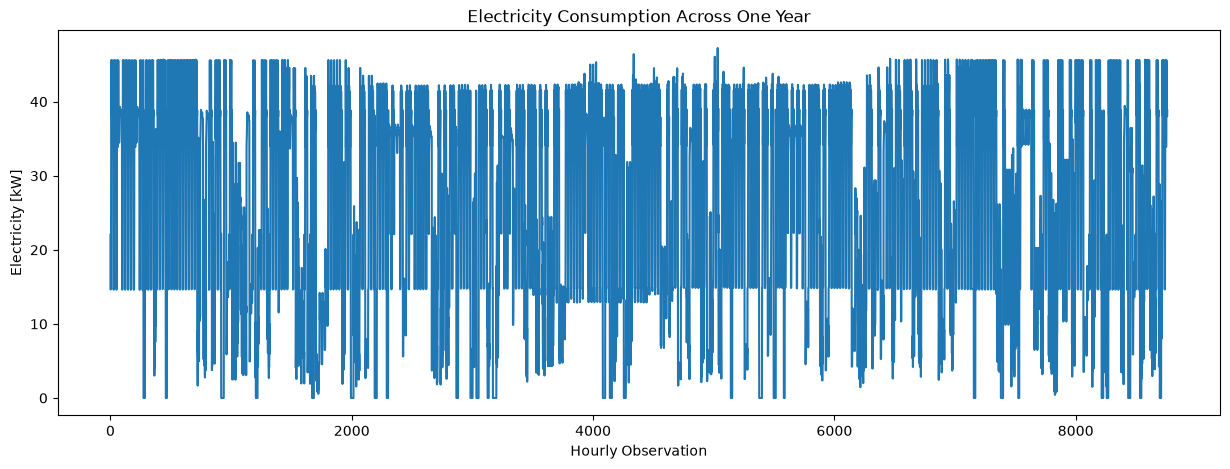

In [198]:
plt.figure(figsize=(15, 5))

plt.plot(
    first_block['Electricity:Facility [kW](Hourly)'].values
)

plt.title('Electricity Consumption Across One Year')
plt.xlabel('Hourly Observation')
plt.ylabel('Electricity [kW]')

plt.show()

### Plot theft/normal over the sequence

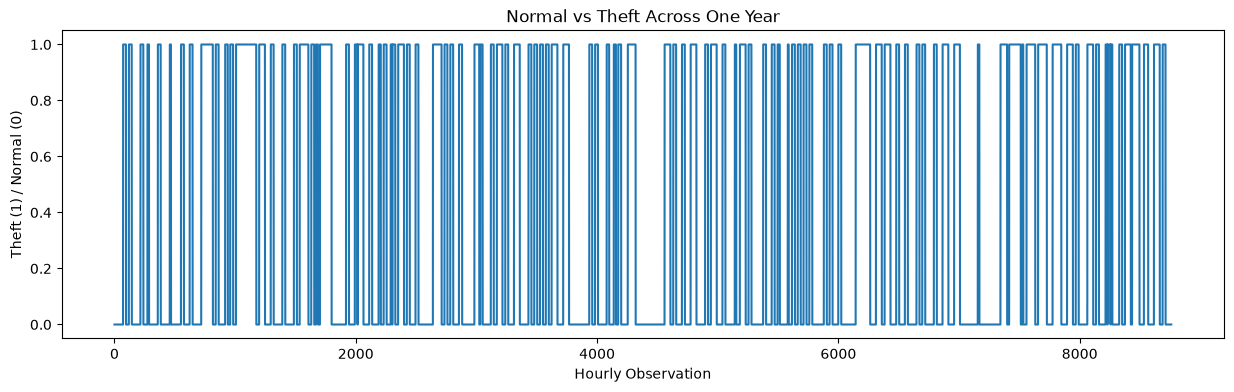

In [199]:
plt.figure(figsize=(15, 4))

plt.plot(
    first_block['theft_binary'].map({
        'Normal': 0,
        'Theft': 1
    }).values
)

plt.title('Normal vs Theft Across One Year')
plt.xlabel('Hourly Observation')
plt.ylabel('Theft (1) / Normal (0)')

plt.show()

### check whether theft is temporarily clustered

In [200]:
theft_numeric = first_block['theft_binary'].map({
    'Normal': 0,
    'Theft': 1
})

theft_changes = theft_numeric.ne(theft_numeric.shift()).sum()

print("Number of Normal/Theft transitions:", theft_changes)

Number of Normal/Theft transitions: 211


### Check consecutive Theft durations

In [201]:
theft_numeric = (
    first_block['theft_binary']
    .eq('Theft')
)

groups = theft_numeric.ne(theft_numeric.shift()).cumsum()

theft_runs = (
    theft_numeric
    .groupby(groups)
    .sum()
)

theft_runs = theft_runs[theft_runs > 0]

theft_runs.describe()

count    105.000000
mean      34.847619
std       24.324244
min        8.000000
25%       24.000000
50%       24.000000
75%       48.000000
max      168.000000
Name: theft_binary, dtype: float64

### Examine the 24-hour structure

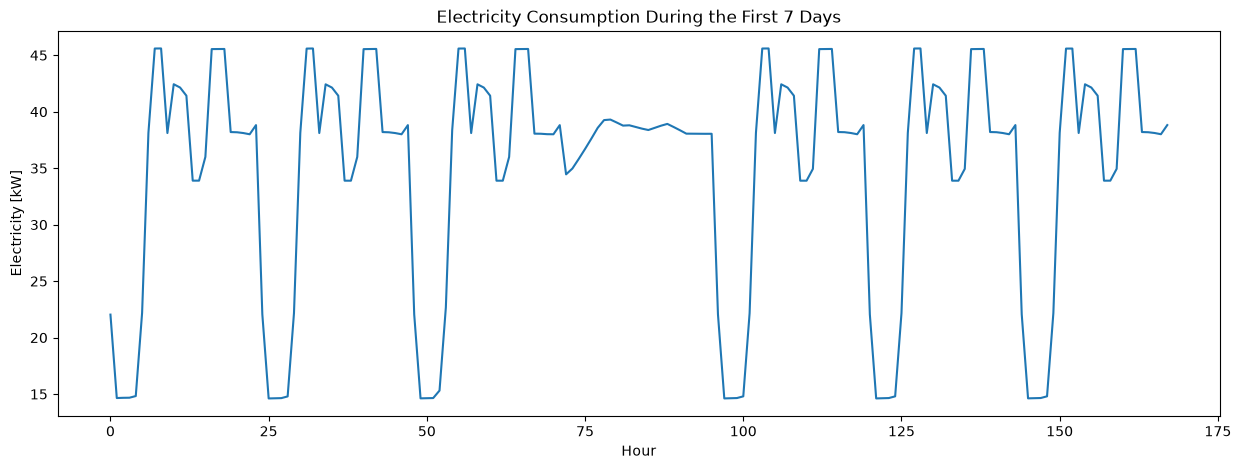

In [202]:
plt.figure(figsize=(15, 5))

plt.plot(
    first_block['Electricity:Facility [kW](Hourly)'].iloc[:24*7].values
)

plt.title('Electricity Consumption During the First 7 Days')
plt.xlabel('Hour')
plt.ylabel('Electricity [kW]')

plt.show()

### Check whether there are repeated daily patterns

In [203]:
facility = first_block[
    'Electricity:Facility [kW](Hourly)'
].values

daily_data = facility[:365*24].reshape(365, 24)

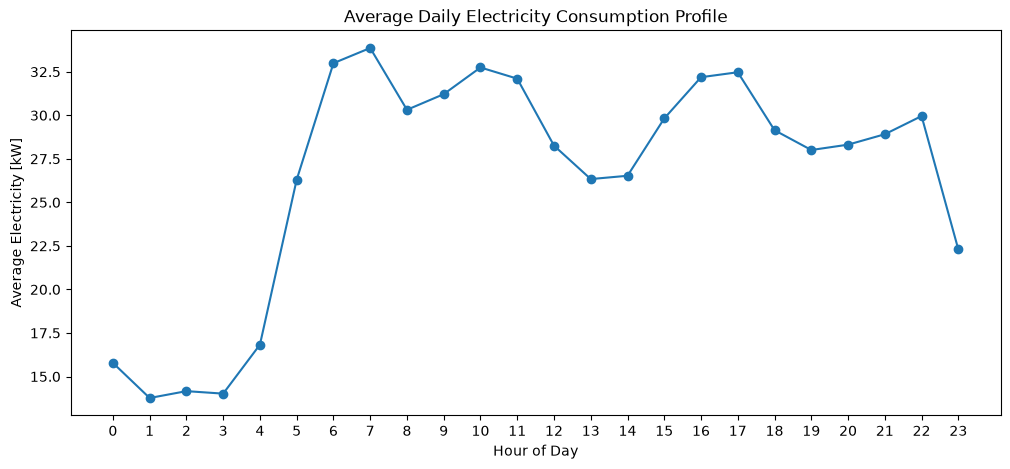

In [204]:
hourly_profile = daily_data.mean(axis=0)

plt.figure(figsize=(12, 5))

plt.plot(range(24), hourly_profile, marker='o')

plt.title('Average Daily Electricity Consumption Profile')
plt.xlabel('Hour of Day')
plt.ylabel('Average Electricity [kW]')

plt.xticks(range(24))

plt.show()

### Compare Normal vs Theft daily profiles

In [205]:
first_block_copy = first_block.copy()

first_block_copy['hour'] = np.arange(len(first_block_copy)) % 24

In [206]:
first_block_copy.groupby(
    ['hour', 'theft_binary']
)['Electricity:Facility [kW](Hourly)'].mean().unstack()

theft_binary,Normal,Theft
hour,,
0,17.023550,13.901897
1,14.743816,12.333538
2,14.756973,13.285109
3,14.695001,13.034546
4,19.093020,13.506583
5,31.760880,18.207921
6,41.277164,21.115723
7,43.109352,20.612589
8,37.401392,20.272088


# **Preprocessing**

1. Confirm that the 8,760 rows are chronological
              Ã¢â€ â€œ
2. Identify each 8,760-row block
              Ã¢â€ â€œ
3. Split each block chronologically
              Ã¢â€ â€œ
4. Create 24-hour sequences
              Ã¢â€ â€œ
5. Scale the features
              Ã¢â€ â€œ
6. Handle class imbalance
              Ã¢â€ â€œ
7. Model

### Check chronological order

In [207]:
# check chronological order
df['block_id'] = df['Class'].ne(df['Class'].shift()).cumsum()

first_block = df[df['block_id'] == 1]

# first 10
first_block[['Class', 'theft_binary'] + energy_cols_reduced].head(10)

,Class,theft_binary,Fans:Electricity [kW](Hourly),Cooling:Electricity [kW](Hourly),Heating:Electricity [kW](Hourly),InteriorLights:Electricity [kW](Hourly),InteriorEquipment:Electricity [kW](Hourly),Gas:Facility [kW](Hourly),InteriorEquipment:Gas [kW](Hourly),Water Heater:WaterSystems:Gas [kW](Hourly)
0,FullServiceRestaurant,Normal,3.586221,0.000000,0.0,4.589925,8.1892,136.585903,3.33988,9.246947
1,FullServiceRestaurant,Normal,0.000000,0.000000,0.0,1.529975,7.4902,3.359880,3.33988,0.020000
2,FullServiceRestaurant,Normal,0.000000,0.000000,0.0,1.529975,7.4902,3.359880,3.33988,0.020000
3,FullServiceRestaurant,Normal,0.000000,0.000000,0.0,1.529975,7.4902,3.931932,3.33988,0.592052
4,FullServiceRestaurant,Normal,0.000000,0.000000,0.0,1.529975,7.4902,3.359880,3.33988,0.020000
5,FullServiceRestaurant,Normal,3.586221,0.013197,0.0,4.589925,8.1892,130.564942,8.34970,0.592057
6,FullServiceRestaurant,Normal,3.586221,0.007371,0.0,9.179851,19.4245,140.435454,16.69940,5.768139
7,FullServiceRestaurant,Normal,3.586221,0.007450,0.0,9.179851,26.9147,135.456017,25.04910,5.193459
8,FullServiceRestaurant,Normal,3.586221,0.000000,0.0,9.179851,26.9147,145.575077,33.39880,5.768467
9,FullServiceRestaurant,Normal,3.586221,0.000000,0.0,9.179851,19.4245,147.695901,25.04910,5.767787


In [208]:
# last 10
first_block[['Class', 'theft_binary'] + energy_cols_reduced].tail(10)

,Class,theft_binary,Fans:Electricity [kW](Hourly),Cooling:Electricity [kW](Hourly),Heating:Electricity [kW](Hourly),InteriorLights:Electricity [kW](Hourly),InteriorEquipment:Electricity [kW](Hourly),Gas:Facility [kW](Hourly),InteriorEquipment:Gas [kW](Hourly),Water Heater:WaterSystems:Gas [kW](Hourly)
8750,FullServiceRestaurant,Normal,3.586221,0.000000,0.0,9.179851,19.4245,145.000561,25.0491,10.997699
8751,FullServiceRestaurant,Normal,3.586221,0.000000,0.0,9.179851,19.4245,146.445416,33.3988,10.997036
8752,FullServiceRestaurant,Normal,3.586221,0.007827,0.0,9.179851,26.9147,156.223386,50.0982,10.996245
8753,FullServiceRestaurant,Normal,3.586221,0.002397,0.0,9.179851,26.9147,156.430910,50.0982,15.094273
8754,FullServiceRestaurant,Normal,3.586221,0.000000,0.0,9.179851,26.9147,155.591038,50.0982,18.054998
8755,FullServiceRestaurant,Normal,3.586221,0.000000,0.0,9.179851,19.4245,137.418074,33.3988,18.055292
8756,FullServiceRestaurant,Normal,3.586221,0.000000,0.0,9.179851,19.4245,130.424326,33.3988,14.514605
8757,FullServiceRestaurant,Normal,3.586221,0.000000,0.0,9.179851,19.4245,134.117636,25.0491,18.636687
8758,FullServiceRestaurant,Normal,3.586221,0.000000,0.0,9.179851,19.4245,125.885592,16.6994,14.511671
8759,FullServiceRestaurant,Normal,3.586221,0.000000,0.0,9.179851,19.4245,107.861805,8.3497,7.506165


In [209]:
# confirming rows in each block
df['block_id'] = df['Class'].ne(df['Class'].shift()).cumsum()

df.groupby('block_id').size().value_counts().sort_index()

6        1
9        1
8760    64
Name: count, dtype: int64

- 64 blocks Ãƒâ€” 8,760 rows = these are full years of hourly data.
- 1 block with 6 rows
- 1 block with 9 rows

The two tiny blocks with 6 and 9 rows are different. They are probably fragments at the boundaries of the dataset rather than complete yearly sequences. For our time-series classification, I wouldn't use those 6- and 9-row blocks, because we're going to need previous 24 hours to predict the next hour. They aren't long enough to form even one 24-hour sequence.

In [210]:
# identifying the two small blocks 
df.groupby('block_id').size().sort_values().head()

block_id
49       6
24       9
3     8760
1     8760
5     8760
dtype: int64

For time-series model, drop blocks 24 and 49 since they are too short to represent a yearly chronological sequence and could cause problems when creating 24-hour windows later.

In [211]:
# dropping block 24 and 49
df = df[~df['block_id'].isin([24, 49])].copy()

In [212]:
df.groupby('block_id').size().value_counts().sort_index()

8760    64
Name: count, dtype: int64

Now we have 64 complete chronological blocks, each containing one year of hourly observations.

## Train/Test split

split within each yearly block, so as to not accidentally mix different building types/years.

- Earlier data - Training
- Later data - Testing

For each block:-
- First 80% - training
- Last 20% - testing

In [213]:
train_parts = []
test_parts = []

for block in df['block_id'].unique():
    block_data = df[df['block_id'] == block]

    split_point = int(len(block_data) * 0.8)

    train_parts.append(block_data.iloc[:split_point])
    test_parts.append(block_data.iloc[split_point:])

train_df = pd.concat(train_parts)
test_df = pd.concat(test_parts)

In [214]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (448512, 13)
Test shape: (112128, 13)


In [215]:
print(train_df.groupby('block_id').size().unique())
print(test_df.groupby('block_id').size().unique())

[7008]
[1752]


### Check the target distribution

Before scaling or creating the 24-hour sequences, make sure the Normal/Theft proportions in train and test are reasonable.

In [216]:
print("Training:")
print(train_df['theft_binary'].value_counts(normalize=True))

print("\nTesting:")
print(test_df['theft_binary'].value_counts(normalize=True))

Training:
theft_binary
Normal    0.593246
Theft     0.406754
Name: proportion, dtype: float64

Testing:
theft_binary
Normal    0.586348
Theft     0.413652
Name: proportion, dtype: float64


Proportions are very similar between training and testing meaning chronological split hasn't created a huge difference in class distribution

### Separate features and target

- turn X into sequences of previous hours.

In [217]:
X_train = train_df.drop(columns=['theft_binary'])
y_train = train_df['theft_binary']

X_test = test_df.drop(columns=['theft_binary'])
y_test = test_df['theft_binary']

In [218]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(448512, 12)
(448512,)
(112128, 12)
(112128,)


Goal: Use the previous 24 hours of energy consumption to predict whether the next hour is Normal or Theft.

Use the energy-consumption columns as the time-series features. Class and block_id, which aren't energy measurements. Don't accidentally feed block_id into the model because it's just an identifier created to keep the sequences separated.

In [219]:
print(X_train.columns.tolist())

['Electricity:Facility [kW](Hourly)', 'Fans:Electricity [kW](Hourly)', 'Cooling:Electricity [kW](Hourly)', 'Heating:Electricity [kW](Hourly)', 'InteriorLights:Electricity [kW](Hourly)', 'InteriorEquipment:Electricity [kW](Hourly)', 'Gas:Facility [kW](Hourly)', 'InteriorEquipment:Gas [kW](Hourly)', 'Water Heater:WaterSystems:Gas [kW](Hourly)', 'Class', 'theft', 'block_id']


use only the 9 energy variables, don't need 'Class' right now because we're trying to answer 'Can the previous 24 hours of energy consumption predict whether the next hour is Normal or Theft?'. Don't want "theft" and "block_id" as input features because:-
- theft is the original target information = target leakage
- block_id is just an identifier Ã¢â€ â€™ it doesn't represent consumption

In [220]:
energy_cols_reduced = [
    'Fans:Electricity [kW](Hourly)',
    'Cooling:Electricity [kW](Hourly)',
    'Heating:Electricity [kW](Hourly)',
    'InteriorLights:Electricity [kW](Hourly)',
    'InteriorEquipment:Electricity [kW](Hourly)',
    'Gas:Facility [kW](Hourly)',
    'InteriorEquipment:Gas [kW](Hourly)',
    'Water Heater:WaterSystems:Gas [kW](Hourly)'
]

X_train = train_df[energy_cols_reduced]
X_test = test_df[energy_cols_reduced]

In [221]:
print(X_train.shape)
print(X_test.shape)

(448512, 8)
(112128, 8)


### Scale features

Use Robustscaler since energy variables are heavily skewed and contain outliers and it is sensitoive to them.

In [222]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [223]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(448512, 8)
(112128, 8)


### Create 24-hour sequences

One important thing: There is need to create sequences within each block_id so a sequence never jumps from the end of one year/block into another.

In [224]:
import numpy as np

def create_sequences(data, target, block_ids, sequence_length=24):
    X_sequences = []
    y_sequences = []

    for block in block_ids.unique():
        block_data = data[block_ids == block]
        block_target = target[block_ids == block]

        for i in range(sequence_length, len(block_data)):
            X_sequences.append(block_data[i-sequence_length:i])
            y_sequences.append(block_target.iloc[i])

    return np.array(X_sequences), np.array(y_sequences)

In [225]:
# run for training data
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train.reset_index(drop=True),
    train_df['block_id'].reset_index(drop=True)
)

In [226]:
print(X_train_seq.shape)
print(y_train_seq.shape)

(446976, 24, 8)
(446976,)


- 446,976 = training sequences
- 24 - each sequence contains 24 hours
- 8 - 8 energy features per hour
- y_train_seq - one Normal/Theft label for each sequence

In [227]:
print(np.unique(y_train_seq, return_counts=True))

(array(['Normal', 'Theft'], dtype='<U6'), array([265136, 181840]))


### Test sequences

In [228]:
X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test.reset_index(drop=True),
    test_df['block_id'].reset_index(drop=True)
)

In [229]:
print(X_test_seq.shape)
print(y_test_seq.shape)

(110592, 24, 8)
(110592,)


In [230]:
print(np.unique(y_test_seq, return_counts=True))

(array(['Normal', 'Theft'], dtype='<U6'), array([65045, 45547]))


# **Dimensionality Reduction**

## PCA

PCA expects a 2D table but currently the sequence is 3D (samples, hours, energy features), therefore, temporarily flatten each 24-hr sequence

In [231]:
# preparing the data
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)

In [232]:
print(X_train_flat.shape)
print(X_test_flat.shape)

(446976, 192)
(110592, 192)


In [233]:
# PCA - FITTING ONLY ON TRAINING DATA
from sklearn.decomposition import PCA

pca = PCA()
X_train_pca = pca.fit_transform(X_train_flat)

In [234]:
# calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

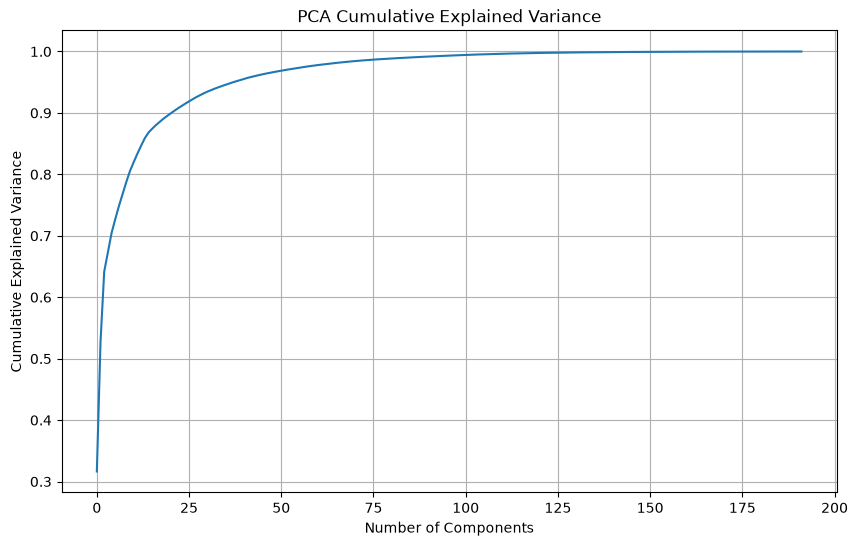

In [235]:
# plotting
plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid()
plt.show()

The curve rises very quickly at the beginning:
- Around 10 components - 86% variance
- Around 25 components - 92%
- Around 50 components - 97%
- Around 75 components - 98.5%
- Around 100 components - 99.5%
After roughly 50 components, the curve starts to flatten considerably, meaning there is a lot of redundancy among the original 192 features

In [236]:
# calculate how many components are needed to retain specific amounts of information
for threshold in [0.90, 0.95, 0.99]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{threshold*100:.0f}% variance: {n_components} components")

90% variance: 22 components
95% variance: 38 components
99% variance: 85 components


Use 38 components (95% variance) because it gives a good balance as data is reduced from 192 to 38 feaures while still retaining 95% of the variance/information. Going to 85 components would keep more information, but the dimensionality reduction becomes much less useful. 22 components is more aggressive and loses 10% of the variance.

In [237]:
# create the 38 component PCA representation
pca_95 = PCA(n_components=38)

X_train_pca = pca_95.fit_transform(X_train_flat)
X_test_pca = pca_95.transform(X_test_flat)

In [238]:
print("Training PCA shape:", X_train_pca.shape)
print("Testing PCA shape:", X_test_pca.shape)

Training PCA shape: (446976, 38)
Testing PCA shape: (110592, 38)


In [239]:
# confirming if still retaining approximately 95%
print("Explained variance:",
      pca_95.explained_variance_ratio_.sum())

Explained variance: 0.9501018038027496


## t-SNE

Visualization technique. Reduce to 2D and plot the observations.

In [240]:
# sampling - take 5000 samples to see structure without making t sne slow
from sklearn.model_selection import train_test_split

X_tsne, _, y_tsne, _ = train_test_split(
    X_train_pca,
    y_train_seq,
    train_size=5000,
    random_state=42,
    stratify=y_train_seq # important because it keeps the normal/theft proportion representative of training data
)

In [241]:
print(X_tsne.shape)
print(y_tsne.shape)

(5000, 38)
(5000,)


In [242]:
# reduce 38 PCA componnets to 2D
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne_2d = tsne.fit_transform(X_tsne)

In [243]:
print(X_tsne_2d.shape)

(5000, 2)


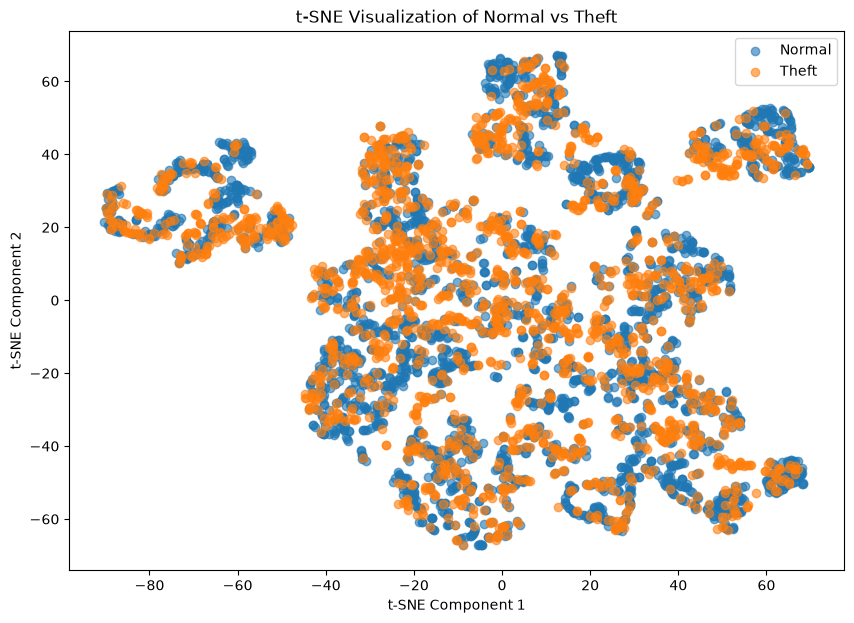

In [244]:
# visualize t SNE results - checking whether Normal and Theft observations form separate regions/clusters would suggest relatively clear separation.
plt.figure(figsize=(10, 7))

for label in ['Normal', 'Theft']:
    mask = y_tsne == label
    plt.scatter(
        X_tsne_2d[mask, 0],
        X_tsne_2d[mask, 1],
        label=label,
        alpha=0.6
    )

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization of Normal vs Theft')
plt.legend()
plt.show()

Normal and Theft overlap heavily suggesting Theft observations have energy-consumption patterns that are quite similar to Normal observations. That's actually interesting for your project because it means detecting theft isn't simply a matter of finding an obviously different consumption group.

The resulting plot showed several local groupings, but substantial overlap between Normal and Theft observations. This suggests that the two classes do not form clearly separable clusters based solely on the 24-hour energy-consumption patterns.

# **Clustering**

use PCA-reduced data (X_train_pca)

# K-Means

In [245]:
# Elbow method
from sklearn.cluster import KMeans

inertias = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_pca)
    inertias.append(kmeans.inertia_)

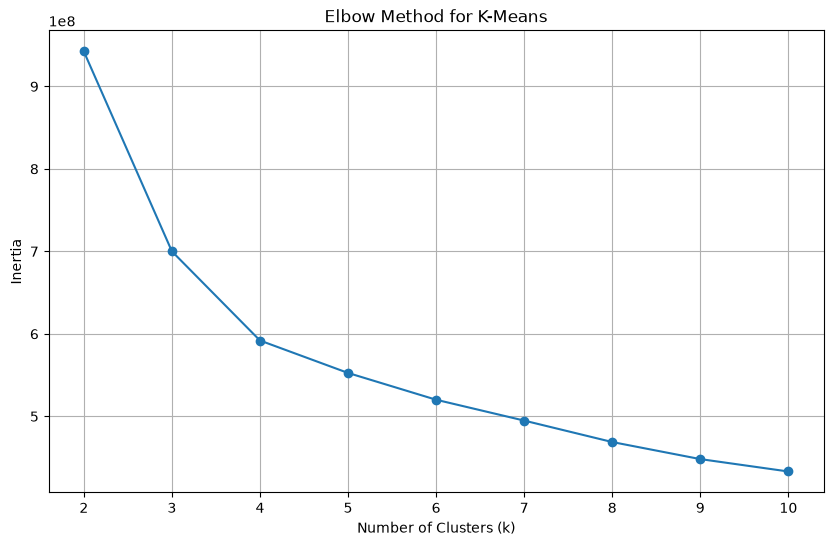

In [246]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertias, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')
plt.xticks(range(2, 11))
plt.grid()
plt.show() 

- 2 Ã¢â€ â€™ 3: very large improvement
- 3 Ã¢â€ â€™ 4: still a substantial improvement
- 4 Ã¢â€ â€™ 5: improvement becomes noticeably smaller
- After 4Ã¢â‚¬â€œ5, the curve gradually flattens.
- k = 4 looks like the elbow.

# Silhouette Score 

to confirm if 4 clusters is a good choice - Because there are 446,976 observations, calculating silhouette on the entire dataset can be very slow, use a representative sample.

In [247]:
from sklearn.metrics import silhouette_score

# calculate for k=2 through k=10
sample_size = 10000

X_sample, _ = train_test_split(
    X_train_pca,
    train_size=sample_size,
    random_state=42
)

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)
    
    print(f"k={k}: Silhouette Score = {score:.4f}")

k=2: Silhouette Score = 0.6648
k=3: Silhouette Score = 0.6778
k=4: Silhouette Score = 0.6922
k=5: Silhouette Score = 0.6108
k=6: Silhouette Score = 0.6123
k=7: Silhouette Score = 0.6227
k=8: Silhouette Score = 0.6212
k=9: Silhouette Score = 0.6270
k=10: Silhouette Score = 0.6256


- NB: The highest silhouette score is generally preferred.
- (k=4), 4 clusters is still preferred as it has the highest score.


In [248]:
# fit our final K-Means model with 4 clusters on the full PCA training data.
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_train_pca)

In [249]:
# check cluster size
print(np.bincount(kmeans_labels))

[377658   5726  22377  41215]


- cluster 0 = 377658
- cluster 1 = 5726
- cluster 2 = 22377
- cluster 3 = 41215

NB: A cluster being small doesn't automatically mean it's wrong. It may represent a particular consumption pattern that occurs much less frequently.

Since PCA components aren't directly intuitive, go back to the original energy features and calculate the average energy consumption for each cluster.
However, remember that clustering observations correspond to the flattened 24-hour sequences. So there is need to summarize each sequence first.

In [250]:
# calculating the mean value of each of the 8 energy features across the 24 hours for every sequence.
X_train_mean = X_train_seq.mean(axis=1)

print(X_train_mean.shape)

(446976, 8)


In [251]:
# combininng averages with K-Means cluster labels and calculate the average consumption for each cluster
# it answers - 'what kind of energy-consumption pattern does each cluster represent?'

cluster_profile = pd.DataFrame(
    X_train_mean,
    columns=X_train.columns
)

cluster_profile['cluster'] = kmeans_labels

cluster_means = cluster_profile.groupby('cluster').mean()

print(cluster_means)

         Fans:Electricity [kW](Hourly)  Cooling:Electricity [kW](Hourly)  \
cluster                                                                    
0                             0.262721                          0.608250   
1                             0.162778                          0.049823   
2                             1.869248                          4.056762   
3                             4.096155                         16.876672   

         Heating:Electricity [kW](Hourly)  \
cluster                                     
0                                0.306273   
1                               28.541975   
2                                0.009698   
3                                0.000000   

         InteriorLights:Electricity [kW](Hourly)  \
cluster                                            
0                                       0.391654   
1                                       0.320054   
2                                       1.040912   
3           

In [252]:
pd.set_option('display.max_columns', None)
print(cluster_means.round(3))

         Fans:Electricity [kW](Hourly)  Cooling:Electricity [kW](Hourly)  \
cluster                                                                    
0                                0.263                             0.608   
1                                0.163                             0.050   
2                                1.869                             4.057   
3                                4.096                            16.877   

         Heating:Electricity [kW](Hourly)  \
cluster                                     
0                                   0.306   
1                                  28.542   
2                                   0.010   
3                                   0.000   

         InteriorLights:Electricity [kW](Hourly)  \
cluster                                            
0                                          0.392   
1                                          0.320   
2                                          1.041   
3           

- Cluster 0: Generally represents a low-energy consumption pattern, with relatively low values across most features.
- Cluster 1: Characterized mainly by high heating electricity consumption (28.542), while cooling and other features remain relatively low. This represents a heating-dominated pattern.
- Cluster 2: Shows relatively high cooling (4.057) and particularly high interior equipment electricity (24.210), indicating an equipment-intensive consumption pattern.
- Cluster 3: Has high fans (4.096), cooling (16.877), and interior lighting (4.038) consumption, representing a high overall electricity-demand pattern, particularly related to cooling.

Overall: K-Means has grouped the 24-hour consumption sequences into four distinct patterns based on similarities in their energy usage. These clusters describe different consumption behaviours, rather than directly representing Normal or Theft.

In [253]:
# investigating 'Do these clusters have anything to do with Normal vs Theft?'
cluster_target = pd.DataFrame({
    'cluster': kmeans_labels,
    'target': y_train_seq
})

print(pd.crosstab(
    cluster_target['cluster'],
    cluster_target['target'],
    normalize='index'
).round(3))

target   Normal  Theft
cluster               
0         0.580  0.420
1         0.732  0.268
2         0.648  0.352
3         0.664  0.336


- Cluster 0: 58.0% Normal and 42.0% Theft. This cluster has the highest proportion of Theft cases.
- Cluster 1: 73.2% Normal and 26.8% Theft. This is the most Normal-dominated cluster.
- Cluster 2: 64.8% Normal and 35.2% Theft.
- Cluster 3: 66.4% Normal and 33.6% Theft.

Overall interpretation:
The clusters contain both Normal and Theft sequences, so there is no cluster that clearly represents Theft or Normal exclusively. Cluster 0 has a somewhat higher concentration of Theft cases, while Cluster 1 is more strongly associated with Normal consumption.

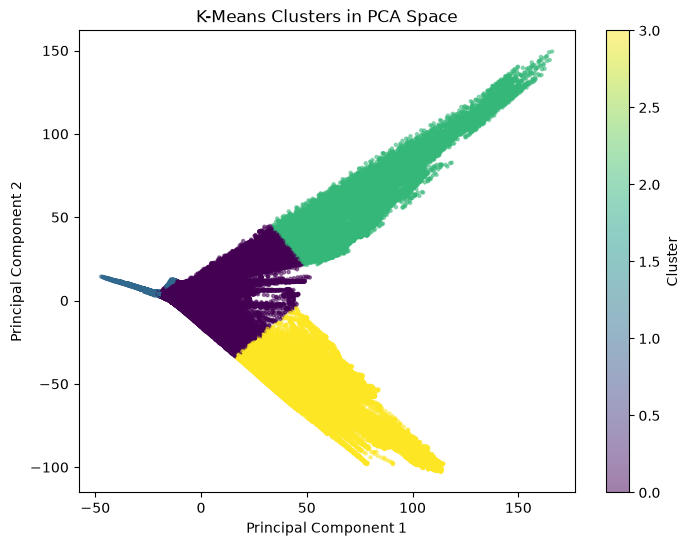

In [254]:
# visualize K-Means clusters using the first two PCA components.
# to see whether the four clusters form distinct groups or whether they overlap substantially.
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=kmeans_labels,
    s=5,
    alpha=0.5
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters in PCA Space')
plt.colorbar(label='Cluster')

plt.show()

- Cluster 0 (purple): Concentrated mainly around the center of the plot and forms the largest central group.
- Cluster 1 (blue): Appears as a relatively small group extending toward the left.
- Cluster 2 (green): Forms a clear elongated group toward the upper-right.
- Cluster 3 (yellow): Forms another clear elongated group toward the lower-right.

The PCA visualization shows that the four K-Means clusters form relatively distinct groups, with particularly clear separation of clusters 2 and 3 from the central cluster. This supports the selection of four clusters based on the elbow method and the highest silhouette score (0.6922). However, the visualization represents only the first two principal components, while clustering was performed using all 38 PCA components.

# DBSCAN

Since DBSCAN can be computationally expensive on 446,976 observations, we'll use the PCA-reduced sample for it. We'll do it one step at a time, just like before.

In [255]:
# create a manageable sample from your PCA data.
X_dbscan, _, y_dbscan, _ = train_test_split(
    X_train_pca,
    y_train_seq,
    train_size=5000,
    random_state=42,
    stratify=y_train_seq
)

print(X_dbscan.shape)

(5000, 38)


In [256]:
# Run DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.0, min_samples=10)

dbscan_labels = dbscan.fit_predict(X_dbscan)

print(pd.Series(dbscan_labels).value_counts())

-1    4401
 0     563
 1      26
 2      10
Name: count, dtype: int64


- 4,401 observations were classified as noise/outliers (-1).
- 563 observations formed Cluster 0.
- 26 observations formed Cluster 1.
- 10 observations formed Cluster 2.
- So about 88% of the sample was treated as noise, which is quite high.
- This suggests that eps=1.0 is too restrictive for our data: DBSCAN is not finding enough dense groups.

In [257]:
# Helps to compare how the number of clusters and noise points changes as eps increases.
for eps in [1.2, 1.5, 2.0]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_dbscan)

    print(f"eps = {eps}")
    print(pd.Series(labels).value_counts().head(10))
    print()

eps = 1.2
-1    4295
 0     651
 1      31
 2      15
 3       8
Name: count, dtype: int64

eps = 1.5
-1    4007
 0     983
 1      10
Name: count, dtype: int64

eps = 2.0
-1    3558
 0    1296
 1      94
 2      16
 4      10
 6      10
 5       8
 3       8
Name: count, dtype: int64



DBSCAN is treating a very large proportion of the observations as noise, even as eps increases.
DBSCAN was tested with different eps values (1.0Ã¢â‚¬â€œ2.0). Increasing eps reduced the number of observations classified as noise and produced more clusters. However, a large proportion of observations remained classified as noise across all tested values. This indicates that the data does not contain many clearly defined dense regions suitable for DBSCAN, unlike the relatively well-separated structure identified by K-Means. No need to keep increasing eps indefinitely just to force DBSCAN to produce more clusters.

In [258]:
# evaluate the DBSCAN result using the silhouette score.
# use eps=2.0 since it produced the most clusters among the values tested and exclude the noise points (-1) from silhouette calculation
# exclude -1 because it represents observations that DBSCAN considers noise, not a genuine cluster. Including them as a cluster would distort the silhouette score.
from sklearn.metrics import silhouette_score

dbscan = DBSCAN(eps=2.0, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_dbscan)

mask = dbscan_labels != -1

silhouette = silhouette_score(
    X_dbscan[mask],
    dbscan_labels[mask]
)

print("Silhouette Score:", round(silhouette, 4))
print("Points used:", mask.sum())

Silhouette Score: 0.3958
Points used: 1442


DBSCAN achieved a silhouette score of 0.3958 when evaluated on the non-noise observations. Only 1,442 of the 5,000 sampled sequences were assigned to clusters, while the remaining observations were classified as noise. Compared with K-Means, which achieved a silhouette score of 0.6922.

DBSCAN produced weaker and less well-defined clusters. Therefore, K-Means provides a more suitable clustering structure for this dataset.

# **Modelling**

# **Classification**

In [259]:
# check class distribution 
print("Training:")
print(pd.Series(y_train_seq).value_counts())

print("\nTest:")
print(pd.Series(y_test_seq).value_counts())

Training:
Normal    265136
Theft     181840
Name: count, dtype: int64

Test:
Normal    65045
Theft     45547
Name: count, dtype: int64


The sequence-level dataset contains approximately 59% Normal and 41% Theft observations in both the training and test sets. Although the classes are not perfectly balanced, the imbalance is moderate. Therefore, the original class distribution is retained rather than applying oversampling, while class-sensitive evaluation metrics will be used to assess model performance.

# 1. Logistic Regression

Just training without evaluating yet

In [260]:
# train
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_flat, y_train_seq)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [261]:
# make predictions on test set
y_pred = lr.predict(X_test_flat)

print(y_pred[:10])

['Normal' 'Normal' 'Normal' 'Normal' 'Normal' 'Normal' 'Normal' 'Normal'
 'Normal' 'Normal']


model's predictions for the first 10 test sequences. It predicted Normal for all 10

In [262]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_seq, y_pred)

print("Accuracy:", round(accuracy, 4))

# calculate balanced accuracy since dataset is imbalanced
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test_seq, y_pred)

print("Balanced Accuracy:", round(balanced_acc, 4))

Accuracy: 0.6904
Balanced Accuracy: 0.635


69.04% of the test sequences were classified correctly

The 63.5% balanced accuracy also shows that performance is not balanced between the two classes, mainly because Normal recall is much higher than Theft recall.

In [263]:
# confusion matrix = classification report
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test_seq, y_pred))

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred))

Confusion Matrix:
[[61726  3319]
 [30921 14626]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.67      0.95      0.78     65045
       Theft       0.82      0.32      0.46     45547

    accuracy                           0.69    110592
   macro avg       0.74      0.64      0.62    110592
weighted avg       0.73      0.69      0.65    110592



- NB: Recall is prioritized because the primary objective of the system is to detect as many actual theft cases as possible. False negatives (missed theft cases) are therefore particularly important. 

Use recall as primary metric because for this project because missing a theft case is more problematic than incorrectly flagging a normal case. Thus, it is more important to determine of all the theft cases, how many did the model successfully detect.

- 61,726 Ã¢â‚¬â€ True Negatives (TN): Normal sequences correctly classified as Normal.
- 3,319 Ã¢â‚¬â€ False Positives (FP): Normal sequences incorrectly classified as Theft.
- 30,921 Ã¢â‚¬â€ False Negatives (FN): Theft sequences incorrectly classified as Normal. These are particularly important because they represent missed theft cases.
- 14,626 Ã¢â‚¬â€ True Positives (TP): Theft sequences correctly detected as Theft.

The model correctly identifies most Normal cases, but it misses a substantial number of Theft cases. Of the 45,547 actual Theft sequences, the model detects only 14,626, giving a Theft recall of 0.32.
This means the baseline Logistic Regression model is currently not very effective at detecting Theft, despite achieving 69.04% overall accuracy.

## Using class_weights 

In [264]:
lr_weighted = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_weighted.fit(X_train_flat, y_train_seq)

y_pred_weighted = lr_weighted.predict(X_test_flat)

In [265]:
# evaluate the weighted Logistic Regression and compare it directly with the baseline.
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score

print("Accuracy:", accuracy_score(y_test_seq, y_pred_weighted))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_seq, y_pred_weighted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_seq, y_pred_weighted))

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred_weighted))

Accuracy: 0.6402000144675926
Balanced Accuracy: 0.6564619567029197

Confusion Matrix:
[[36700 28345]
 [11446 34101]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.76      0.56      0.65     65045
       Theft       0.55      0.75      0.63     45547

    accuracy                           0.64    110592
   macro avg       0.65      0.66      0.64    110592
weighted avg       0.67      0.64      0.64    110592



- 34,101 Theft cases were correctly detected
- 11,446 Theft cases were missed
- The baseline missed 30,921 theft cases, whereas the weighted model misses only 11,446 which is a huge improvement in the project's main objective.

The class-weighted Logistic Regression improved Theft recall substantially from 32% to 75% and increased balanced accuracy from 63.5% to 65.65%. Although overall accuracy decreased from 69.04% to 64.02%, the weighted model is more suitable for theft detection because it identifies a much larger proportion of actual theft cases. The improvement in Theft recall comes at the cost of lower Theft precision and more false positives.

### NB:
 SMOTE was not applied because the sequence-level class distribution was only moderately imbalanced (59% Normal, 41% Theft), and class weighting was used instead. Class weighting improved Theft recall from 32% to 75% while preserving the chronological structure of the time-series data.

# 2. Random Forest

In [266]:
# train
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train_flat, y_train_seq)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [267]:
# evaluate
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, balanced_accuracy_score

y_pred_rf = rf.predict(X_test_flat)

print("Accuracy:", accuracy_score(y_test_seq, y_pred_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_seq, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_seq, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred_rf))

Accuracy: 0.9281322337962963
Balanced Accuracy: 0.9189622817758285

Confusion Matrix:
[[63157  1888]
 [ 6060 39487]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.97      0.94     65045
       Theft       0.95      0.87      0.91     45547

    accuracy                           0.93    110592
   macro avg       0.93      0.92      0.92    110592
weighted avg       0.93      0.93      0.93    110592



- The Random Forest achieved an accuracy of 92.81%, meaning it correctly classified about 93% of the test sequences.
- The balanced accuracy was 91.90%, indicating that the model performs well across both Normal and Theft classes rather than favoring only the larger class.
- For Theft, the model achieved 87% recall, meaning it successfully detected 87% of the actual theft cases.
- For Normal, recall was 97%, meaning most Normal cases were correctly identified.
- From the confusion matrix, the model correctly identified 39,487 Theft cases and missed 6,060 Theft cases.
- It incorrectly classified 1,888 Normal cases as Theft, which represents the model's false alarms.

Overall, the results indicate that the Random Forest is highly effective at distinguishing Normal and Theft consumption patterns in the test sequences.

In [268]:
df.dtypes

Electricity:Facility [kW](Hourly)             float64
Fans:Electricity [kW](Hourly)                 float64
Cooling:Electricity [kW](Hourly)              float64
Heating:Electricity [kW](Hourly)              float64
InteriorLights:Electricity [kW](Hourly)       float64
InteriorEquipment:Electricity [kW](Hourly)    float64
Gas:Facility [kW](Hourly)                     float64
InteriorEquipment:Gas [kW](Hourly)            float64
Water Heater:WaterSystems:Gas [kW](Hourly)    float64
Class                                             str
theft                                             str
theft_binary                                      str
block_id                                        int64
dtype: object

# 3. LSTM (Long Short-Term Memory)

In [269]:
# prepare the target
# LSTM works better with numerical labels

y_train_lstm = (y_train_seq == 'Theft').astype(int)
y_test_lstm = (y_test_seq == 'Theft').astype(int)

In [270]:
print(y_train_lstm.shape)
print(y_test_lstm.shape)

(446976,)
(110592,)


In [272]:
print(X_train.shape)
print(y_train.shape)

(448512, 8)
(448512,)


In [274]:
# create 24-hour sequence
import numpy as np

def create_sequences(X, y, timesteps=24):
    X = np.asarray(X)
    y = np.asarray(y)

    X_seq = []
    y_seq = []

    for i in range(timesteps, len(X)):
        X_seq.append(X[i-timesteps:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

In [275]:
X_train_seq, y_train_seq = create_sequences(X_train, y_train, 24)

X_test_seq, y_test_seq = create_sequences(X_test, y_test, 24)

print(X_train_seq.shape)
print(y_train_seq.shape)
print(X_test_seq.shape)
print(y_test_seq.shape)

(448488, 24, 8)
(448488,)
(112104, 24, 8)
(112104,)


In [ ]:
# create lstm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

model = Sequential([
    LSTM(64, input_shape=(24, 8)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\User\Documents\Advanced_ML_Capstone_Project\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â³Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€â€œ
Ã¢â€Æ’ Layer (type)                    Ã¢â€Æ’ Output Shape           Ã¢â€Æ’       Param # Ã¢â€Æ’
Ã¢â€Â¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€¢â€¡Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â©
Ã¢â€â€š lstm_2 (LSTM)                   Ã¢â€â€š (None, 64)             Ã¢â€â€š        18,688 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š dropout_2 (Dropout)             Ã¢â€â€š (None, 64)             Ã¢â€â€š             0 Ã¢â€â€š
Ã¢â€Å“Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¼Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â¤
Ã¢â€â€š dense_2 (Dense)                 Ã¢â€â€š (None, 1)              Ã¢â€â€š            65 Ã¢â€â€š
Ã¢â€â€Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â´Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Â´Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€Ëœ

 Total params: 18,753 (73.25 KB)

 Trainable params: 18,753 (73.25 KB)

 Non-trainable params: 0 (0.00 B)

LSTM = (None, 64)
- The LSTM has 64 units.
- None represents the batch size, which is determined when you train/predict.
- Since the LSTM outputs (None, 64) rather than a sequence such as (None, 24, 64), you're using the final LSTM output to make the prediction.

Dropout = (None, 64), 0 parameters
- Dropout doesn't learn weights.
- It simply randomly drops some of the 64 LSTM outputs during training to reduce overfitting.

Dense = (None, 1), 65 parameters
- This converts the 64 LSTM outputs into one prediction.
- Parameters: 64 * 1 + 1 = 65

Overall:
The LSTM takes your sequence of electricity-consumption features, compresses the sequence into 64 learned representations, applies dropout and then uses those 64 values to produce one Normal/Theft prediction.

In [280]:
print(y_train.dtype)
print(y_train[:10])
print(y_train.unique())

str
0    Normal
1    Normal
2    Normal
3    Normal
4    Normal
5    Normal
6    Normal
7    Normal
8    Normal
9    Normal
Name: theft_binary, dtype: str
<StringArray>
['Normal', 'Theft']
Length: 2, dtype: str


In [281]:
# converting to binary target since they are string
y_train = y_train.map(lambda x: 0 if x == 'Normal' else 1)
y_test = y_test.map(lambda x: 0 if x == 'Normal' else 1)

In [282]:
# recreate sequence since y_train_seq created earlier contains old string labels
X_train_seq, y_train_seq = create_sequences(X_train, y_train, 24)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, 24)

In [283]:
print(X_train_seq.dtype)
print(y_train_seq.dtype)
print(np.unique(y_train_seq))

float64
int64
[0 1]


In [288]:
# train on smaller sample because 448, 888 is a larger sample and was taking 23 mins+
X_train_small = X_train_seq[:100000]
y_train_small = y_train_seq[:100000]

print(X_train_small.shape)

(100000, 24, 8)


In [289]:
# train
history = model.fit(
    X_train_small,
    y_train_small,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    shuffle=False
)

Epoch 1/5
1250/1250 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 17s 13ms/step - accuracy: 0.8714 - loss: 0.3419 - val_accuracy: 0.8495 - val_loss: 0.3528
Epoch 2/5
1250/1250 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 14s 12ms/step - accuracy: 0.8609 - loss: 0.3553 - val_accuracy: 0.8568 - val_loss: 0.3421
Epoch 3/5
1250/1250 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 16s 13ms/step - accuracy: 0.8772 - loss: 0.3317 - val_accuracy: 0.8455 - val_loss: 0.3633
Epoch 4/5
1250/1250 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 15s 12ms/step - accuracy: 0.8767 - loss: 0.3275 - val_accuracy: 0.8209 - val_loss: 0.4

Training accuracy: 86.1% Ã¢â€ â€™ 88.3%
Validation accuracy: 85.7% Ã¢â€ â€™ 82.4%

And validation loss goes:
0.342 Ã¢â€ â€™ 0.422

That's a sign of overfitting.
The model is becoming increasingly good at recognizing the training data, but its ability to generalize to unseen data is getting worse.

Overall:

Epoch 2 is the best validation result

In [291]:
# use early stopping so model automatically stops when validation performance stops improving.
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_small,
    y_train_small,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    shuffle=False,
    callbacks=[early_stop]
)

Epoch 1/10
1250/1250 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 18s 14ms/step - accuracy: 0.8825 - loss: 0.3158 - val_accuracy: 0.8436 - val_loss: 0.3748
Epoch 2/10
1250/1250 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 19s 15ms/step - accuracy: 0.8872 - loss: 0.3092 - val_accuracy: 0.8662 - val_loss: 0.3397
Epoch 3/10
1250/1250 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 17s 13ms/step - accuracy: 0.8850 - loss: 0.3098 - val_accuracy: 0.8500 - val_loss: 0.3731
Epoch 4/10
1250/1250 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 19s 15ms/step - accuracy: 0.8905 - loss: 0.3021 - val_accuracy: 0.8645 - val_loss:

- It stopped after Epoch 4 because the validation loss wasn't improving enough. 
- Epoch 2 is the best epoch because it has the lowest validation loss (0.3397)

In [292]:
# evaluate lstm on test data
test_loss, test_accuracy = model.evaluate(
    X_test_seq,
    y_test_seq,
    batch_size=64
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1752/1752 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 12s 7ms/step - accuracy: 0.8352 - loss: 0.4210
Test Loss: 0.4209900200366974
Test Accuracy: 0.8352065682411194


In [296]:
# get actual predictions
y_pred_prob = model.predict(X_test_seq, batch_size=64)

y_pred = (y_pred_prob >= 0.4).astype(int).flatten()

1752/1752 Ã¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€ÂÃ¢â€Â 11s 6ms/step


In [297]:
# generate classification report
from sklearn.metrics import classification_report

print(classification_report(
    y_test_seq,
    y_pred,
    target_names=['Normal', 'Theft']
))

              precision    recall  f1-score   support

      Normal       0.83      0.89      0.86     65722
       Theft       0.83      0.74      0.78     46382

    accuracy                           0.83    112104
   macro avg       0.83      0.82      0.82    112104
weighted avg       0.83      0.83      0.83    112104



When the model predicts that something is theft, it is correct about 74% of the time when looking at recall.

In [298]:
# confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_seq, y_pred)

print(cm)

[[58798  6924]
 [12044 34338]]


- 58,798 Ã¢â€ â€™ correctly identified Normal
- 6,924 Ã¢â€ â€™ Normal incorrectly flagged as Theft
- 34,338 Ã¢â€ â€™ correctly identified Theft 
- 12,044 Ã¢â€ â€™ Theft incorrectly classified as Normal

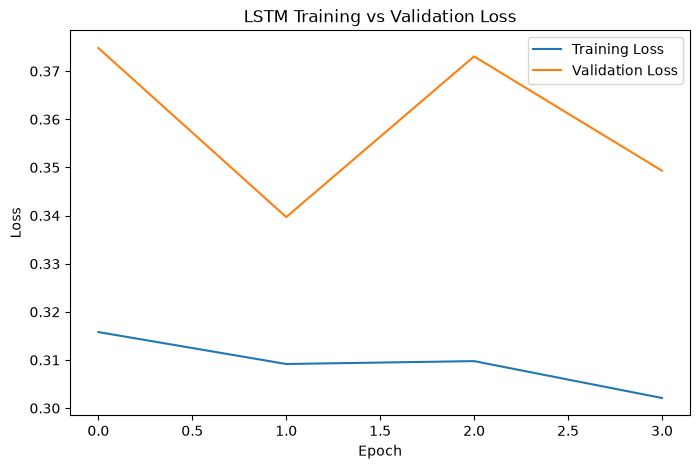

In [300]:
# plot training history
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training vs Validation Loss')
plt.legend()
plt.show()

- Training loss steadily decreases from about 0.316 to 0.302. This means the LSTM continues to improve its performance on the training data.
- Validation loss decreases initially, reaching its lowest point of about 0.340 at Epoch 2, then increases at Epoch 3.
- This suggests that after Epoch 2, the model begins to overfit: it continues learning the training data while its performance on unseen validation data starts getting worse.
- This is why EarlyStopping stopped the training after Epoch 4 and with restore_best_weights=True, retained the weights from the best validation epoch.

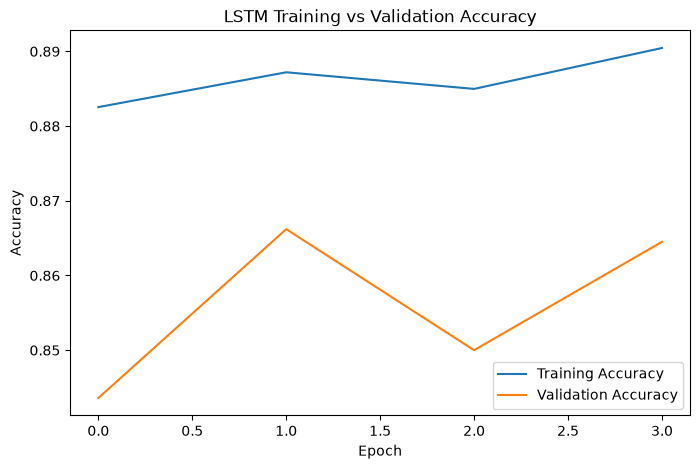

In [301]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('LSTM Training vs Validation Accuracy')
plt.legend()
plt.show()

The training accuracy increased throughout the training process, reaching approximately 89%, while validation accuracy reached its highest value of 86.6% at Epoch 2. The subsequent decline in validation accuracy while training accuracy remained high indicates the onset of overfitting. Early stopping was therefore used to retain the model weights from the best-performing validation epoch.

# Model Comparison

In [302]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'LSTM'
    ],
    'Accuracy': [
        0.6402,
        0.9281,
        0.8308
    ],
    'Balanced Accuracy': [
        0.6565,
        0.9190,
        None
    ],
    'Theft Precision': [
        0.55,
        0.95,
        0.83
    ],
    'Theft Recall': [
        0.75,
        0.87,
        0.74
    ],
    'Theft F1': [
        0.63,
        0.91,
        0.78
    ]
})

comparison

,Model,Accuracy,Balanced Accuracy,Theft Precision,Theft Recall,Theft F1
0,Logistic Regression,0.6402,0.6565,0.55,0.75,0.63
1,Random Forest,0.9281,0.9190,0.95,0.87,0.91
2,LSTM,0.8308,NaN,0.83,0.74,0.78


Three models were evaluated for electricity theft detection: class-weighted Logistic Regression, Random Forest, and LSTM. Random Forest achieved the best overall performance, with a Theft recall of 87%, correctly identifying 39,487 of the 45,547 actual theft cases. The LSTM achieved a Theft recall of 74%, while class-weighted Logistic Regression achieved 75%. Therefore, Random Forest was selected as the best-performing model for electricity theft detection.

# Feature Importance for Random Forest

Feature importance answers:
"Which parts of the previous 24-hour electricity pattern were most useful to the Random Forest when deciding Normal vs Theft?"

In [305]:
print("Number of features in X_train:", X_train.shape[1])
print("Number of importances:", len(rf.feature_importances_))

Number of features in X_train: 8
Number of importances: 192


In [306]:
print(X_train.columns)

Index(['Fans:Electricity [kW](Hourly)', 'Cooling:Electricity [kW](Hourly)',
       'Heating:Electricity [kW](Hourly)',
       'InteriorLights:Electricity [kW](Hourly)',
       'InteriorEquipment:Electricity [kW](Hourly)',
       'Gas:Facility [kW](Hourly)', 'InteriorEquipment:Gas [kW](Hourly)',
       'Water Heater:WaterSystems:Gas [kW](Hourly)'],
      dtype='str')


In [307]:
print(X_train.shape)
print(len(rf.feature_importances_))

(448512, 8)
192


In [308]:
print(rf.n_features_in_)

192


In [310]:
print(X_train_flat.shape)

(446976, 192)


In [318]:
print(energy_cols_reduced)

['Fans:Electricity [kW](Hourly)', 'Cooling:Electricity [kW](Hourly)', 'Heating:Electricity [kW](Hourly)', 'InteriorLights:Electricity [kW](Hourly)', 'InteriorEquipment:Electricity [kW](Hourly)', 'Gas:Facility [kW](Hourly)', 'InteriorEquipment:Gas [kW](Hourly)', 'Water Heater:WaterSystems:Gas [kW](Hourly)']


In [319]:
# giving every feature correct name
feature_names = []

for hour in range(1, 25):
    for feature in energy_cols_reduced:
        feature_names.append(f'Hour {hour} - {feature}')

print(len(feature_names))

192


In [320]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(20))

                                               Feature  Importance
188  Hour 24 - InteriorEquipment:Electricity [kW](H...    0.041970
187  Hour 24 - InteriorLights:Electricity [kW](Hourly)    0.033595
180  Hour 23 - InteriorEquipment:Electricity [kW](H...    0.033323
184            Hour 24 - Fans:Electricity [kW](Hourly)    0.027136
191  Hour 24 - Water Heater:WaterSystems:Gas [kW](H...    0.025044
179  Hour 23 - InteriorLights:Electricity [kW](Hourly)    0.022136
176            Hour 23 - Fans:Electricity [kW](Hourly)    0.019010
190       Hour 24 - InteriorEquipment:Gas [kW](Hourly)    0.018949
164  Hour 21 - InteriorEquipment:Electricity [kW](H...    0.016549
172  Hour 22 - InteriorEquipment:Electricity [kW](H...    0.016238
183  Hour 23 - Water Heater:WaterSystems:Gas [kW](H...    0.016103
171  Hour 22 - InteriorLights:Electricity [kW](Hourly)    0.015909
168            Hour 22 - Fans:Electricity [kW](Hourly)    0.015532
163  Hour 21 - InteriorLights:Electricity [kW](Hourly)    0.01

Look at your top 20:
> - InteriorEquipment:Electricity appears repeatedly in Hours 21Ã¢â‚¬â€œ24.
> - InteriorLights:Electricity appears repeatedly in Hours 20Ã¢â‚¬â€œ24.
> - Fans:Electricity appears in Hours 22Ã¢â‚¬â€œ24.
> - Water Heater:Gas appears in Hours 21Ã¢â‚¬â€œ24.
> - InteriorEquipment:Gas appears in Hours 23Ã¢â‚¬â€œ24.
> - Gas:Facility appears in Hour 24.

- Importantly, this does not mean those variables cause theft. It means their observed consumption patterns are particularly useful for the model's predictions.


Feature importance analysis showed that recent consumption patterns were particularly influential in the Random Forest model. The most important feature was Interior Equipment Electricity consumption at Hour 24, followed by Interior Lights Electricity at Hour 24 and Interior Equipment Electricity at Hour 23. Most of the highly ranked features occurred between Hours 20 and 24 of the 24-hour observation window. This indicates that the most recent consumption behaviour contained substantial information for distinguishing normal electricity consumption from theft.

This is actually a nice finding for the project, because it supports the idea behind the time-series approach: the recent history of consumption contains useful information for theft detection.

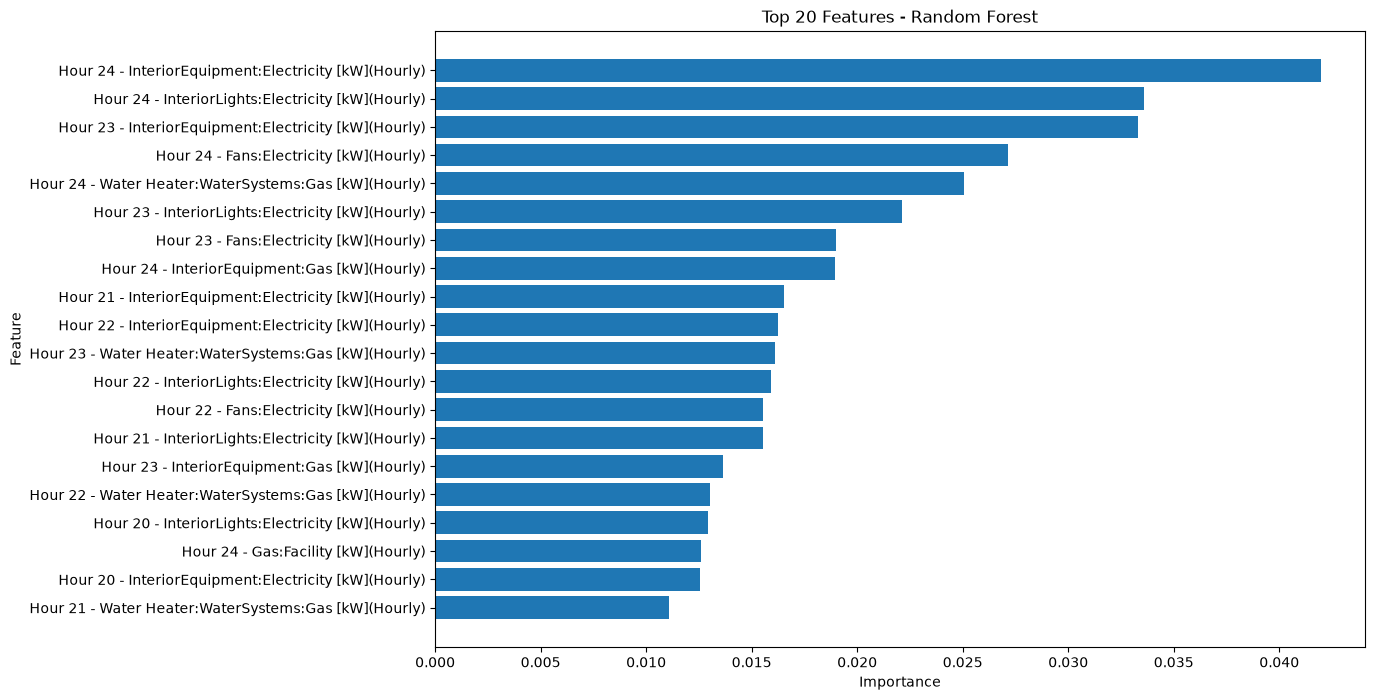

In [321]:
# plot top 20
top_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Features - Random Forest')
plt.gca().invert_yaxis()

plt.show()

### Interpretation of the Top 20 Features graph
This chart shows the hourly variables that most strongly influenced the Random Forest predictions. The features at the top have the highest importance values, so they were the strongest indicators for distinguishing normal consumption from electricity theft. In this model, the most important signals appear in the final hours of the day (around 20:00 to 24:00), which suggests that recent usage patterns carry the most predictive information. Features such as interior equipment electricity, interior lighting electricity, and fan electricity repeatedly appear near the top, which indicates that abnormal evening or late-night activity is a useful signal for theft detection.

This graph is valuable because it helps identify which time-specific signals the model is actually learning from; it does not prove that these variables cause theft, only that they are highly informative for classification.


In [ ]:
# OVERALL IMPORTANCE BY ENERGY TYPE - Combines the 24 hourly importance values for each of your 8 original features
# Create a table with the original feature for each of the 192 features
importance_by_type = pd.DataFrame({
    'Feature': energy_cols_reduced,
    'Importance': [
        feature_importance.iloc[i::8]['Importance'].sum()
        for i in range(8)
    ]
})

importance_by_type = importance_by_type.sort_values(
    'Importance',
    ascending=False
)

print(importance_by_type)

                                      Feature  Importance
0               Fans:Electricity [kW](Hourly)    0.146654
1            Cooling:Electricity [kW](Hourly)    0.136201
2            Heating:Electricity [kW](Hourly)    0.134436
3     InteriorLights:Electricity [kW](Hourly)    0.125422
4  InteriorEquipment:Electricity [kW](Hourly)    0.121164
5                   Gas:Facility [kW](Hourly)    0.116759
6          InteriorEquipment:Gas [kW](Hourly)    0.110525
7  Water Heater:WaterSystems:Gas [kW](Hourly)    0.108839


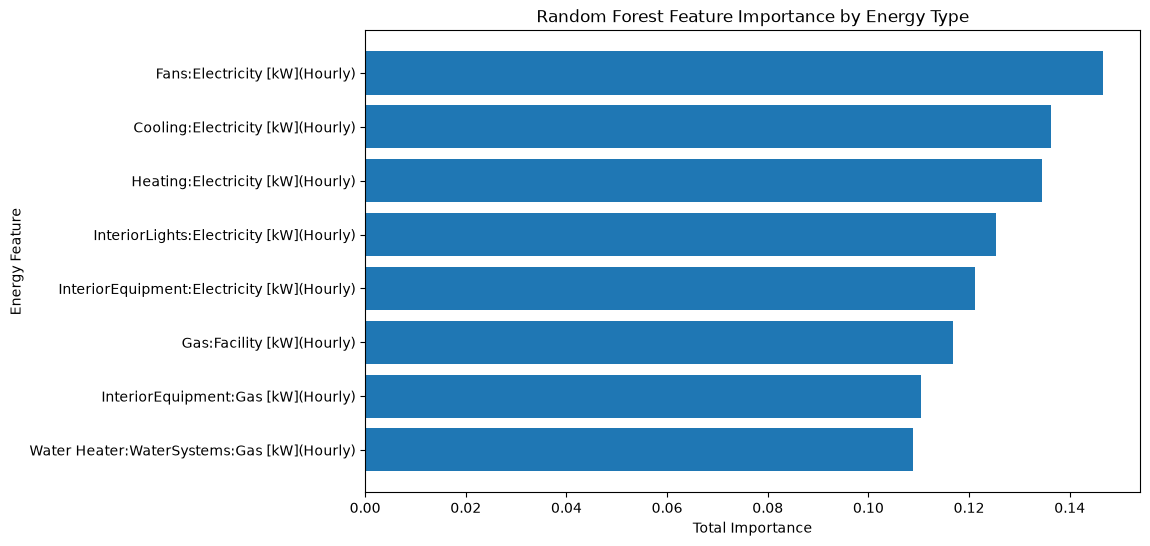

In [323]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_by_type['Feature'],
    importance_by_type['Importance']
)

plt.xlabel('Total Importance')
plt.ylabel('Energy Feature')
plt.title('Random Forest Feature Importance by Energy Type')
plt.gca().invert_yaxis()

plt.show()

This answers: Across the entire 24-hour window, which types of energy consumption were most useful to the Random Forest for detecting electricity theft?

### Interpretation of the Overall Importance by Energy Type graph
This chart combines the importance values across the full 24-hour window for each main energy category. It answers a broader question: across the full day, which energy types contribute the most to the models decisions? A larger bar means the model relies more heavily on that energy source when classifying a case. If categories like interior equipment, lighting, or fans dominate, it suggests those systems show the clearest difference between normal and suspicious consumption patterns.

This is especially useful for feature selection and for understanding where abnormal behavior is concentrated. It also helps prioritize investigation: if one type of energy consumption is consistently more important, it is likely the most informative signal in the dataset. As with all feature-importance plots, the result reflects model usefulness rather than direct causality.


# **Error Analysis**

In [344]:
actual_labels = np.where(y_test_seq == 0, 'Normal', 'Theft')

In [345]:
# Create predictions using the same sequence-aligned test data
X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)
y_pred_rf = rf.predict(X_test_flat)

# Align labels with the same sequence-level test data
error_analysis = pd.DataFrame({
    'Actual': actual_labels,
    'Predicted': y_pred_rf
})

# Check whether each prediction matches the true class
error_analysis['Correct'] = error_analysis['Actual'] == error_analysis['Predicted']

error_analysis.head()


,Actual,Predicted,Correct
0,Normal,Normal,True
1,Normal,Theft,False
2,Normal,Theft,False
3,Normal,Theft,False
4,Normal,Theft,False


In [346]:
# count correct vs incorrect predictions
error_analysis['Correct'].value_counts()

Correct
True     57079
False    55025
Name: count, dtype: int64

The False number is the total number of errors your Random Forest made on the sequence-level test set
- 57,079 correct predictions
- 55,025 incorrect predictions
- Total = 112,104

In [347]:
# see actual errors
errors = error_analysis[error_analysis['Correct'] == False]

errors.head()

,Actual,Predicted,Correct
1,Normal,Theft,False
2,Normal,Theft,False
3,Normal,Theft,False
4,Normal,Theft,False
5,Normal,Theft,False


- The Random Forest is sometimes flagging normal electricity consumption as theft. That's important because a real electricity-theft detection system could potentially cause false alarms if this happens frequently.
- Initial error analysis shows that the Random Forest produces both correct and incorrect classifications. The first incorrectly classified observations indicate false positives, where normal electricity consumption is classified as theft. However, further analysis using the confusion matrix is required to determine the overall distribution of false positives and false negatives.

### Confusion Matrix

In [349]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    error_analysis['Actual'],
    error_analysis['Predicted'],
    labels=['Normal', 'Theft']
)

print(cm)

[[18683 47039]
 [ 7986 38396]]


In [350]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 18683
False Positives: 47039
False Negatives: 7986
True Positives  : 38396


- So the model is much more likely to over-flag normal consumption as theft than to miss actual theft.

Error analysis revealed that the Random Forest produced substantially more false positives (47,039) than false negatives (7,986). The model correctly detected 38,396 theft observations, corresponding to a theft recall of approximately 82.8%. However, it incorrectly classified 47,039 normal observations as theft, resulting in a low ability to correctly identify normal consumption. This indicates that although the model is relatively effective at detecting theft, it tends to over-classify normal consumption as theft.

### Checking how normal observations that were incorrectly classified as theft look like


In [353]:
# separate the two groups
# Correctly classified Normal observations
correct_normal = error_analysis[
    (error_analysis['Actual'] == 'Normal') &
    (error_analysis['Predicted'] == 'Normal')
]

# Normal observations incorrectly classified as Theft
false_positives = error_analysis[
    (error_analysis['Actual'] == 'Normal') &
    (error_analysis['Predicted'] == 'Theft')
]

print("Correct Normal:", len(correct_normal))
print("False Positives:", len(false_positives))

Correct Normal: 18683
False Positives: 47039


In [354]:
# get original sequence data for those observations
# Get the positions of false positives
fp_indices = error_analysis.index[
    (error_analysis['Actual'] == 'Normal') &
    (error_analysis['Predicted'] == 'Theft')
]

# Get their original 24-hour sequences
X_fp = X_test_seq[fp_indices]

print(X_fp.shape)

(47039, 24, 8)


In [355]:
# compare average consumption pattern
fp_mean = X_fp.mean(axis=0)

print(fp_mean)

[[ 11.37782355  21.83958768   2.0750567   31.33643675  39.90669519
   98.06115932   5.19295013  13.01985306]
 [ 11.63646175  22.4208626    2.1041899   32.46919063  41.07407154
  100.32243125   5.76681765  13.60646813]
 [ 11.85791668  22.89014238   2.15694589  33.45627254  42.14478625
  101.91388304   6.27924589  13.80385719]
 [ 12.07526335  23.2060212    2.2173428   34.45314505  43.00303723
  103.637911     6.66216889  13.99238882]
 [ 12.28406202  23.58225533   2.26755274  35.16051207  43.64069955
  105.48404372   7.03372262  14.07838308]
 [ 12.44839104  23.78394819   2.30549818  35.7658028   44.31032286
  106.14505769   7.37163888  13.83942302]
 [ 12.66750704  23.95888538   2.33774222  36.17326843  44.57039581
  107.80897331   7.68519607  13.55731645]
 [ 12.8749647   24.12752055   2.3630305   36.48136887  44.78558752
  110.11947974   7.83932655  13.24001131]
 [ 12.93037331  24.35937085   2.29158888  36.98247918  44.89466204
  110.67120101   7.93704975  12.9591191 ]
 [ 12.88239311  24.

In [358]:
# calculate average across all 24 hours for each feature
fp_feature_mean = X_fp.mean(axis=(0, 1))

print(fp_feature_mean)

[ 12.3076491   24.21303137   2.15525076  33.71766597  42.93884615
 103.41436333   6.27916556  13.56237485]


In [359]:
fp_summary = pd.DataFrame({
    'Feature': energy_cols_reduced,
    'Average_Consumption': fp_feature_mean
})

fp_summary

,Feature,Average_Consumption
0,Fans:Electricity [kW](Hourly),12.307649
1,Cooling:Electricity [kW](Hourly),24.213031
2,Heating:Electricity [kW](Hourly),2.155251
3,InteriorLights:Electricity [kW](Hourly),33.717666
4,InteriorEquipment:Electricity [kW](Hourly),42.938846
5,Gas:Facility [kW](Hourly),103.414363
6,InteriorEquipment:Gas [kW](Hourly),6.279166
7,Water Heater:WaterSystems:Gas [kW](Hourly),13.562375


The normal observations incorrectly classified as theft have substantial energy consumption, particularly in facility gas, interior equipment, and interior lighting. This suggests that some normal high-consumption patterns may resemble the consumption patterns associated with theft, making them difficult for the Random Forest to distinguish.

In [356]:
# compare against correctly classified normal observations
normal_indices = error_analysis.index[
    (error_analysis['Actual'] == 'Normal') &
    (error_analysis['Predicted'] == 'Normal')
]

X_correct_normal = X_test_seq[normal_indices]

normal_mean = X_correct_normal.mean(axis=0)

print(normal_mean.shape)

(24, 8)


In [363]:
correct_normal_mean = X_correct_normal.mean(axis=(0, 1))

comparison = pd.DataFrame({
    'Feature': energy_cols_reduced,
    'False_Positive': fp_feature_mean,
    'Correct_Normal': correct_normal_mean
})

comparison

,Feature,False_Positive,Correct_Normal
0,Fans:Electricity [kW](Hourly),12.307649,19.016711
1,Cooling:Electricity [kW](Hourly),24.213031,49.135173
2,Heating:Electricity [kW](Hourly),2.155251,1.448683
3,InteriorLights:Electricity [kW](Hourly),33.717666,38.710942
4,InteriorEquipment:Electricity [kW](Hourly),42.938846,51.428452
5,Gas:Facility [kW](Hourly),103.414363,158.004966
6,InteriorEquipment:Gas [kW](Hourly),6.279166,13.818982
7,Water Heater:WaterSystems:Gas [kW](Hourly),13.562375,22.876759


The false-positive cases tend to have lower overall energy consumption than correctly classified Normal cases. This suggests that the model may struggle to recognize certain moderate or lower-consumption Normal patterns, causing them to be incorrectly classified as Theft.

### Look at false negatives

In [364]:
# extract the false negative sequence
false_negatives = error_analysis[
    (error_analysis['Actual'] == 'Theft') &
    (error_analysis['Predicted'] == 'Normal')
]

fn_indices = false_negatives.index

X_fn = X_test_seq[fn_indices]

print("False negatives:", len(false_negatives))
print("X_fn shape:", X_fn.shape)

False negatives: 7986
X_fn shape: (7986, 24, 8)


The false-negative analysis showed that 7,986 Theft observations were incorrectly classified as Normal. These missed Theft cases exhibited relatively substantial consumption, particularly for Gas:Facility, Cooling, and InteriorEquipment. This suggests that the model is not simply missing theft because of low consumption. Instead, some theft patterns may resemble normal high-consumption patterns, making them difficult for the Random Forest to distinguish from legitimate consumption.

In [365]:
# average consumption
fn_feature_mean = X_fn.mean(axis=(0, 1))

fn_feature_mean

array([ 21.83910528,  60.89713486,   0.70095653,  42.05178697,
        52.90586744, 181.10617361,  15.84286001,  31.71833879])

The missed Theft cases actually show fairly substantial consumption, especially:
- Gas:Facility Ã¢â€ â€™ 181.11
- Cooling Ã¢â€ â€™ 60.90
- InteriorEquipment Ã¢â€ â€™ 52.91
- Water Heater Gas Ã¢â€ â€™ 31.72

So the model isn't missing Theft simply because these cases have very low consumption.

The interesting part is that these Theft patterns may resemble normal high-consumption patterns. Remember that our correctly classified Normal cases also had relatively high averages.

So the model appears to have difficulty distinguishing between high/moderate consumption that is genuinely Theft and high/moderate consumption that is genuinely Normal.

In [367]:
# compare missed theft cases with correctly detected theft cases
correct_theft = error_analysis[
    (error_analysis['Actual'] == 'Theft') &
    (error_analysis['Predicted'] == 'Theft')
]

ct_indices = correct_theft.index
X_correct_theft = X_test_seq[ct_indices]

correct_theft_mean = X_correct_theft.mean(axis=(0, 1))

comparison_theft = pd.DataFrame({
    'Feature': energy_cols_reduced,
    'False_Negative': fn_feature_mean,
    'Correct_Theft': correct_theft_mean
})

comparison_theft

,Feature,False_Negative,Correct_Theft
0,Fans:Electricity [kW](Hourly),21.839105,9.672460
1,Cooling:Electricity [kW](Hourly),60.897135,20.544852
2,Heating:Electricity [kW](Hourly),0.700957,1.405490
3,InteriorLights:Electricity [kW](Hourly),42.051787,25.541240
4,InteriorEquipment:Electricity [kW](Hourly),52.905867,33.116185
5,Gas:Facility [kW](Hourly),181.106174,81.362027
6,InteriorEquipment:Gas [kW](Hourly),15.842860,5.770270
7,Water Heater:WaterSystems:Gas [kW](Hourly),31.718339,11.536471


- The Theft cases that the model misses actually have much higher consumption than the Theft cases it correctly detects. This suggests the Random Forest may not be distinguishing the classes based on overall consumption magnitude alone. The shape/timing of the 24-hour consumption pattern may be more important.

Comparing false-negative cases with correctly classified Theft cases showed that the Theft observations missed by the Random Forest generally had substantially higher consumption levels. The largest differences were observed for Gas:Facility, Cooling, InteriorEquipment, and Water Heater Gas. This indicates that the model may struggle to identify certain high-consumption theft patterns, possibly because their 24-hour consumption patterns resemble normal consumption patterns. Therefore, overall consumption magnitude alone may not be sufficient to distinguish between Normal and Theft observations.

In [368]:
# compare average 24-hour pattern
# Average consumption at each hour across all false negatives
fn_hourly_mean = X_fn.mean(axis=0)

# Average consumption at each hour across correctly classified Theft
correct_theft_hourly_mean = X_correct_theft.mean(axis=0)

print("False Negative shape:", fn_hourly_mean.shape)
print("Correct Theft shape:", correct_theft_hourly_mean.shape)

False Negative shape: (24, 8)
Correct Theft shape: (24, 8)


In [370]:
# calc difference for each energy source
comparison_theft['Difference'] = (
    comparison_theft['False_Negative'] -
    comparison_theft['Correct_Theft']
)

comparison_theft[['Feature', 'Difference']].sort_values(
    'Difference',
    ascending=False
)

,Feature,Difference
5,Gas:Facility [kW](Hourly),99.744146
1,Cooling:Electricity [kW](Hourly),40.352283
7,Water Heater:WaterSystems:Gas [kW](Hourly),20.181867
4,InteriorEquipment:Electricity [kW](Hourly),19.789682
3,InteriorLights:Electricity [kW](Hourly),16.510547
0,Fans:Electricity [kW](Hourly),12.166645
6,InteriorEquipment:Gas [kW](Hourly),10.072590
2,Heating:Electricity [kW](Hourly),-0.704533


The comparison between false-negative and correctly classified Theft cases showed that the missed Theft cases generally had higher consumption across most energy sources. The largest difference was observed in Gas:Facility consumption (+99.74 kW), followed by Cooling (+40.35 kW). Water Heater Gas, InteriorEquipment, InteriorLights, Fans, and InteriorEquipment Gas also showed higher consumption among the false negatives. Heating was the only feature with a slightly lower value. This indicates that the Theft cases missed by the model are characterized by substantially higher consumption in several energy sources, particularly facility gas and cooling.

We've answered an important question:
"What kind of errors is the Random Forest making?"
- False positives: Normal cases being flagged as Theft.
- False negatives: Theft cases being missed, particularly those with high Gas:Facility and Cooling consumption.

In [ ]:
# find when the difference occurs between gas:facility and cooling since they are the two features that showed biggest gap
# This will tell us at which hours the missed Theft cases have substantially higher consumption than the correctly detected Theft cases.

# Gas:Facility (feature index 5)
gas_hourly_difference = (
    fn_hourly_mean[:, 5] -
    correct_theft_hourly_mean[:, 5]
)

# Cooling (feature index 1)
cooling_hourly_difference = (
    fn_hourly_mean[:, 1] -
    correct_theft_hourly_mean[:, 1]
)

print("Gas:Facility hourly differences:")
print(gas_hourly_difference)

print("\nCooling hourly differences:")
print(cooling_hourly_difference)

Gas:Facility hourly differences:
[ 88.95526037  80.37965471  74.32713791  69.08750329  64.53727427
  65.7420345   66.00597726  71.45140575  75.55664273  78.75029725
  81.80955951  84.49496534  91.34998047  99.81822756 104.36897471
 110.27264882 118.93465701 128.26086868 137.12443592 141.03112798
 142.43205682 140.67809364 139.91197038 138.57875822]

Cooling hourly differences:
[41.46384781 38.74323814 37.02891332 35.72724008 34.73010432 34.42397834
 34.29212268 34.5793447  34.85648215 34.89456523 35.28674286 35.41082661
 36.20666238 37.55987254 39.15627405 40.43838187 42.83343323 45.49568804
 47.75559327 48.91634179 49.38398197 49.84760514 50.00769725 49.41585179]


- The Theft cases missed by the model appear to have substantially higher Gas:Facility and Cooling consumption, with the difference becoming particularly pronounced during the later hours of the 24-hour sequence. This could mean that the temporal pattern of consumption matters, especially later in the day.

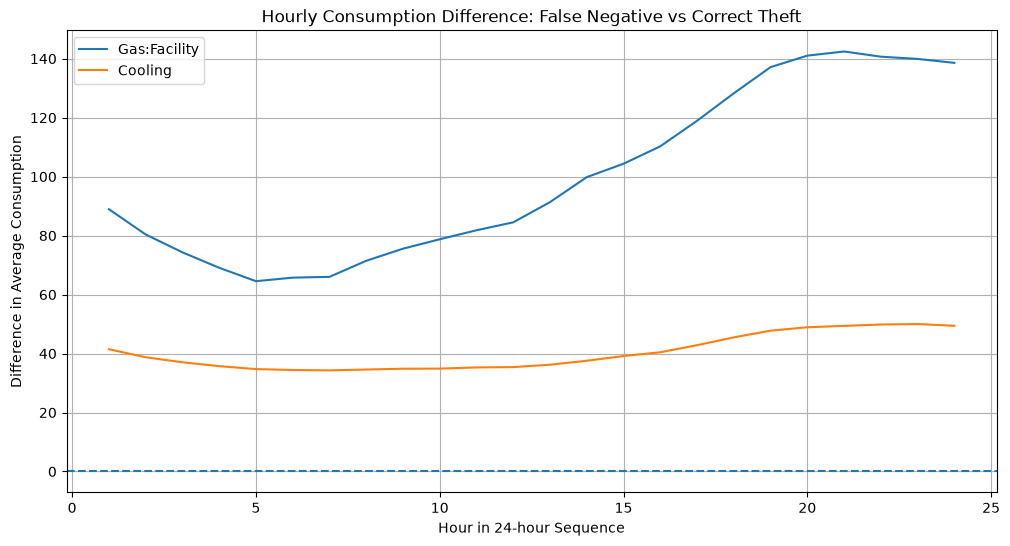

In [372]:
# visualize
plt.figure(figsize=(12, 6))

plt.plot(
    range(1, 25),
    gas_hourly_difference,
    label='Gas:Facility'
)

plt.plot(
    range(1, 25),
    cooling_hourly_difference,
    label='Cooling'
)

plt.axhline(0, linestyle='--')

plt.xlabel('Hour in 24-hour Sequence')
plt.ylabel('Difference in Average Consumption')
plt.title('Hourly Consumption Difference: False Negative vs Correct Theft')
plt.legend()
plt.grid()
plt.show()

In [374]:
# calculate final evaluation metrics
# Convert predicted labels to numeric format
y_pred_rf_numeric = np.where(y_pred_rf == 'Theft', 1, 0)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test_seq, y_pred_rf_numeric)
balanced_accuracy = balanced_accuracy_score(y_test_seq, y_pred_rf_numeric)

precision = precision_score(y_test_seq, y_pred_rf_numeric, pos_label=1)
recall = recall_score(y_test_seq, y_pred_rf_numeric, pos_label=1)
f1 = f1_score(y_test_seq, y_pred_rf_numeric, pos_label=1)

print("Final Random Forest Evaluation")
print("--------------------------------")
print(f"Accuracy:           {accuracy:.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy:.4f}")
print(f"Precision:          {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"F1-Score:           {f1:.4f}")

Final Random Forest Evaluation
--------------------------------
Accuracy:           0.5092
Balanced Accuracy:  0.5560
Precision:          0.4494
Recall:             0.8278
F1-Score:           0.5826


- The model is good at catching Theft, but poor at confidently distinguishing Theft from Normal consumption.

The Random Forest is good at detecting theft (high recall) but produces many false alarms (low precision). The error analysis suggests that the model struggles particularly with distinguishing certain normal and high-consumption theft patterns.

Overall, the Random Forest demonstrates good sensitivity to theft but has limited ability to distinguish theft from normal consumption, resulting in a high false-alarm rate.

# **Save trained random forest**

In [376]:
import joblib

joblib.dump(rf, 'random_forest_theft_model.pkl')

['random_forest_theft_model.pkl']

In [377]:
# save the 8 features so streamlit uses the exact same input order as training
joblib.dump(energy_cols_reduced, 'energy_features.pkl')

['energy_features.pkl']

In [378]:
# save already fitted scaler
joblib.dump(scaler, 'robust_scaler.pkl')

['robust_scaler.pkl']

In [379]:

print(X_train_flat.shape)
print(rf.n_features_in_)

(446976, 192)
192
